# Project 2 — Exploratory Data Analysis (EDA)

This project uses the cleaned dataset from Project 1 to explore the data and understand its patterns, trends, distributions, relationships, and unusual values.

The goal is to move from a cleaned dataset to useful observations and insights.

In [1]:
import pandas as pd

## Load the Dataset

The cleaned dataset produced in Project 1 will be used as the starting point for this analysis.

In [2]:
df = pd.read_excel("../data/input/cleaned_dataset.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.shape

(1200, 14)

## Starting Point

The dataset contains 1,200 records and 14 columns.

It has already been cleaned and validated in Project 1, so this project will focus on exploring the data and finding useful patterns and insights.

## Understand the Dataset

Before starting the analysis, I will review the columns, data types, and basic structure of the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

### Numerical and Categorical Fields

The dataset contains both numerical and categorical fields.

The numerical fields will be useful for calculating statistics and studying distributions, while the categorical fields will help compare groups and identify patterns.

In [6]:
numeric_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical columns:
['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']


### Initial Observation

The numerical fields will be the main focus for descriptive statistics and distribution analysis. The categorical fields will be useful later when comparing orders, products, payment methods, order statuses, coupon usage, and referral sources.

## Descriptive Statistics

I will first look at the main numerical fields using descriptive statistics.

This will help me understand the typical values, the spread of the data, and the range of each numerical variable before looking at individual distributions.

In [7]:
summary_stats = df[numeric_columns].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


## Count, Mean, and Median

The mean and median will be compared for each numerical field.

Looking at both measures is useful because a large difference between them can indicate that the distribution is influenced by unusually high or low values.

In [8]:
basic_stats = pd.DataFrame({
    "count": df[numeric_columns].count(),
    "mean": df[numeric_columns].mean().round(2),
    "median": df[numeric_columns].median().round(2)
})

basic_stats

,count,mean,median
Quantity,1200,2.95,3.00
UnitPrice,1200,356.41,364.21
ItemsInCart,1200,5.48,5.00
TotalPrice,1200,1053.97,823.62


### Initial Statistical Observation

The descriptive statistics give a first view of the typical values and spread of the numerical fields.

The mean and median will be compared more closely later when the distributions are visualized and investigated for possible outliers.

## Five-Number Summary

The five-number summary shows the minimum, first quartile (Q1), median, third quartile (Q3), and maximum for each numerical variable.

This gives a quick view of the centre and spread of the data.

In [9]:
five_number_summary = pd.DataFrame({
    "Minimum": df[numeric_columns].min(),
    "Q1": df[numeric_columns].quantile(0.25),
    "Median": df[numeric_columns].median(),
    "Q3": df[numeric_columns].quantile(0.75),
    "Maximum": df[numeric_columns].max()
}).round(2)

five_number_summary

,Minimum,Q1,Median,Q3,Maximum
Quantity,1.00,2.00,3.00,4.00,5.00
UnitPrice,11.39,186.06,364.21,521.57,699.93
ItemsInCart,1.00,4.00,5.00,7.00,10.00
TotalPrice,11.39,410.52,823.62,1578.48,3456.40


## Distribution of Numerical Variables

The distribution of a variable helps show where most values are concentrated and whether the data appears fairly balanced or skewed.

Histograms are used below to visually examine the shape of the numerical variables.

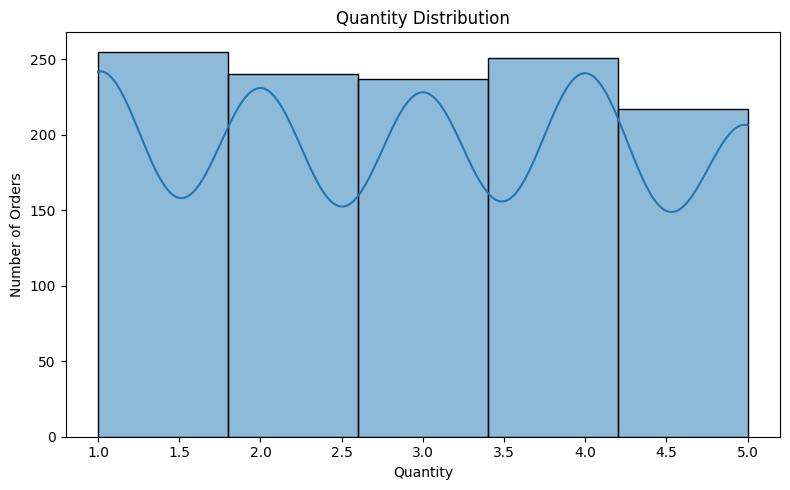

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["Quantity"], bins=5, kde=True)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/01_quantity_distribution.png", dpi=300)
plt.show()

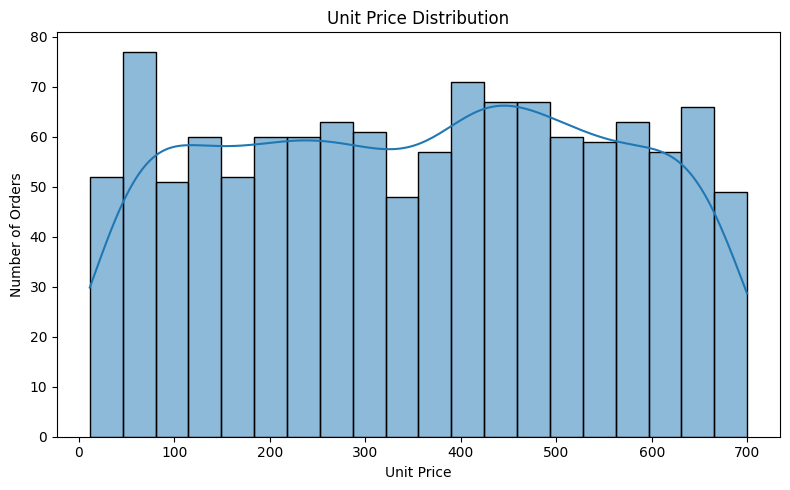

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df["UnitPrice"], bins=20, kde=True)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/02_unit_price_distribution.png", dpi=300)
plt.show()

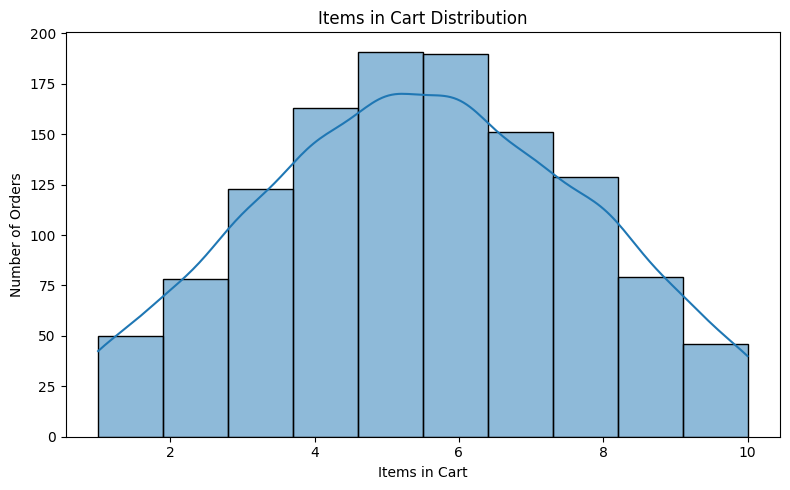

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["ItemsInCart"], bins=10, kde=True)

plt.title("Items in Cart Distribution")
plt.xlabel("Items in Cart")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/03_items_in_cart_distribution.png", dpi=300)
plt.show()

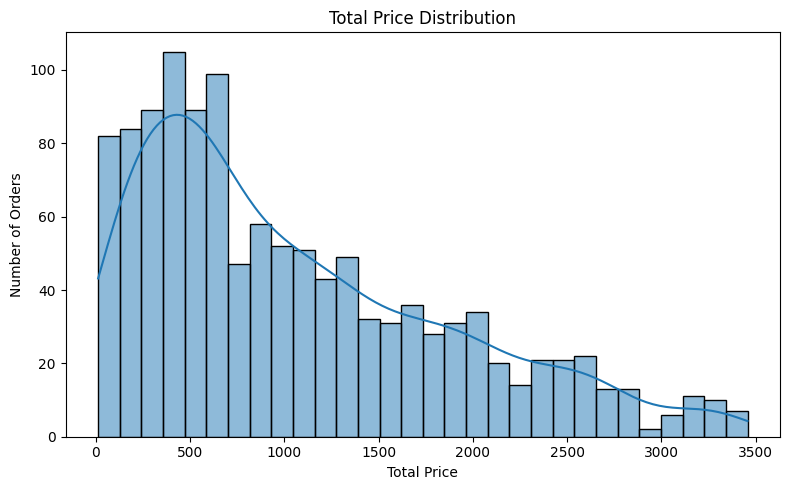

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["TotalPrice"], bins=30, kde=True)

plt.title("Total Price Distribution")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig("../images/04_total_price_distribution.png", dpi=300)
plt.show()

### Distribution Shape

To support the visual analysis, skewness is calculated for each numerical variable.

A value close to zero suggests a more balanced distribution, while a larger positive or negative value indicates greater asymmetry.

In [14]:
distribution_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Skewness": df[numeric_columns].skew()
}).round(2)

distribution_summary

,Mean,Median,Skewness
Quantity,2.95,3.00,0.03
UnitPrice,356.41,364.21,-0.03
ItemsInCart,5.48,5.00,0.00
TotalPrice,1053.97,823.62,0.89


## Mean vs Median

The mean and median are compared to see whether they are close to each other or whether there is a noticeable difference.

A small difference suggests that the values are relatively balanced, while a larger difference can indicate that some values are pulling the mean away from the median.

In [15]:
mean_median_comparison = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median()
})

mean_median_comparison["Difference"] = (
    mean_median_comparison["Mean"] -
    mean_median_comparison["Median"]
)

mean_median_comparison["Gap %"] = (
    mean_median_comparison["Difference"].abs() /
    mean_median_comparison["Median"].replace(0, pd.NA) * 100
)

mean_median_comparison.round(2)

,Mean,Median,Difference,Gap %
Quantity,2.95,3.00,-0.05,1.81
UnitPrice,356.41,364.21,-7.80,2.14
ItemsInCart,5.48,5.00,0.49,9.70
TotalPrice,1053.97,823.62,230.35,27.97


### Mean and Median Observation

The mean and median are very close for `Quantity` and `UnitPrice`, suggesting that these variables are relatively balanced around their typical values.

`ItemsInCart` shows a larger difference between the mean and median, indicating some asymmetry in the distribution.

The largest difference is seen in `TotalPrice`, where the mean is noticeably higher than the median. This suggests that higher-value orders are pulling the average upward.

The distribution charts support this observation and show that `TotalPrice` is more unevenly distributed than the other numerical variables.

## Task 2 Summary

The descriptive analysis provides a basic understanding of the numerical variables in the dataset.

- The dataset contains 1,200 observations for each numerical variable.
- `Quantity`, `UnitPrice`, `ItemsInCart`, and `TotalPrice` were examined using count, mean, median, and the five-number summary.
- The distribution charts show how the values are spread across each numerical variable.
- Mean and median are relatively close for `Quantity` and `UnitPrice`.
- `TotalPrice` has the largest difference between its mean and median, suggesting that higher-value orders have an influence on the average.
- These observations provide a basis for further investigation in the next stages of the EDA.

## Trends and Outliers

This part of the analysis looks at how the data changes over time and whether there are unusual observations that need further investigation.

For the trend analysis, I will look at monthly order activity and total sales.

### Preparing the Data for Trend Analysis

The `Date` column will be used to organize the records by month.

Before looking at the trend, I will check the date range and create a monthly summary of the number of orders and total sales.

In [16]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2023-01-01 00:00:00
End date: 2025-06-30 00:00:00


In [17]:
monthly_summary = (
    df.set_index("Date")
      .resample("ME")
      .agg(
          Orders=("OrderID", "count"),
          TotalSales=("TotalPrice", "sum")
      )
      .reset_index()
)

monthly_summary

,Date,Orders,TotalSales
0,2023-01-31,47,56685.75
1,2023-02-28,37,40117.66
2,2023-03-31,43,48609.37
3,2023-04-30,31,27751.71
4,2023-05-31,49,63836.84
5,2023-06-30,45,49500.19
6,2023-07-31,44,42820.66
7,2023-08-31,51,54352.14
8,2023-09-30,29,29526.67
9,2023-10-31,47,52607.85


### Initial Trend View

The monthly summary provides a simpler view of how order activity and sales change over the period covered by the dataset.

This summary will be used to create the trend visualizations in the next step.

## Monthly Trends

The monthly summary is visualized below to make changes in order activity and total sales easier to see.

Looking at both measures together helps show whether changes in sales are accompanied by similar changes in the number of orders.

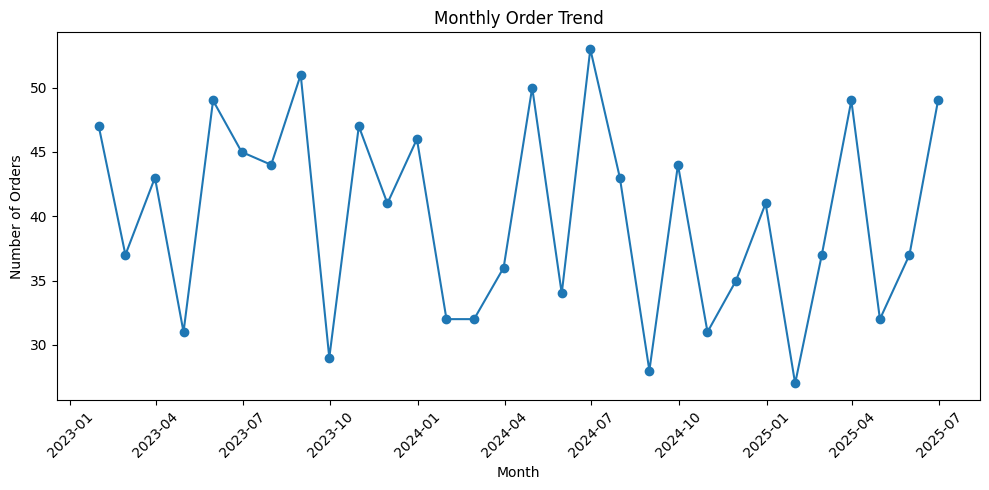

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary["Date"],
    monthly_summary["Orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/05_monthly_order_trend.png", dpi=300)
plt.show()

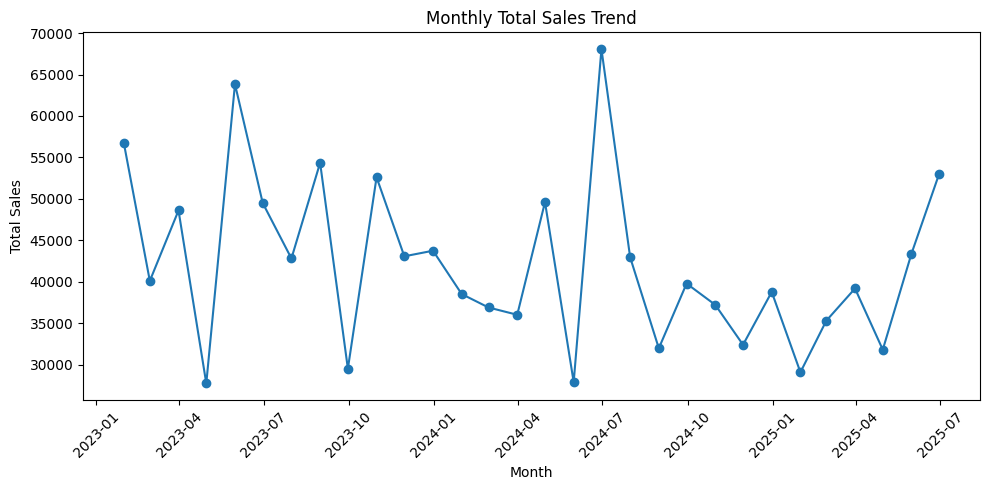

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary["Date"],
    monthly_summary["TotalSales"],
    marker="o"
)

plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/06_monthly_total_sales_trend.png", dpi=300)
plt.show()

### Trend Observation

The monthly order and sales charts show that both measures fluctuate across the period rather than following a steady upward or downward pattern.

Some months show higher order activity and sales, while other months are noticeably lower. The two measures generally move in a similar direction, although the changes are not identical in every month.

The monthly trends will be used as the basis for identifying the more noticeable peaks and dips in the next part of the analysis.

## Finding Important Trend Points

The charts show that both order volume and total sales change from month to month.

To identify the more important changes, I will look at the months with the highest and lowest order counts and sales values. I will also compare each month with the previous month to find larger increases and decreases.

In [20]:
highest_orders = monthly_summary.loc[
    monthly_summary["Orders"].idxmax()
]

lowest_orders = monthly_summary.loc[
    monthly_summary["Orders"].idxmin()
]

highest_sales = monthly_summary.loc[
    monthly_summary["TotalSales"].idxmax()
]

lowest_sales = monthly_summary.loc[
    monthly_summary["TotalSales"].idxmin()
]

print("Highest number of orders:")
print(highest_orders)

print("\nLowest number of orders:")
print(lowest_orders)

print("\nHighest total sales:")
print(highest_sales)

print("\nLowest total sales:")
print(lowest_sales)

Highest number of orders:
Date          2024-06-30 00:00:00
Orders                         53
TotalSales               68068.54
Name: 17, dtype: object

Lowest number of orders:
Date          2025-01-31 00:00:00
Orders                         27
TotalSales                29099.4
Name: 24, dtype: object

Highest total sales:
Date          2024-06-30 00:00:00
Orders                         53
TotalSales               68068.54
Name: 17, dtype: object

Lowest total sales:
Date          2023-04-30 00:00:00
Orders                         31
TotalSales               27751.71
Name: 3, dtype: object


### Highest and Lowest Months

The highest and lowest months provide a simple way to identify where order activity and sales were strongest and weakest during the period.

These points will be compared with the monthly trend charts to see whether unusually strong or weak months appear in both measures.

In [21]:
monthly_summary["OrderChange"] = (
    monthly_summary["Orders"].diff()
)

monthly_summary["SalesChange"] = (
    monthly_summary["TotalSales"].diff()
)

monthly_summary["OrderChangePct"] = (
    monthly_summary["Orders"].pct_change() * 100
)

monthly_summary["SalesChangePct"] = (
    monthly_summary["TotalSales"].pct_change() * 100
)

monthly_summary.round(2)

,Date,Orders,TotalSales,OrderChange,SalesChange,OrderChangePct,SalesChangePct
0,2023-01-31,47,56685.75,NaN,NaN,NaN,NaN
1,2023-02-28,37,40117.66,-10.0,-16568.09,-21.28,-29.23
2,2023-03-31,43,48609.37,6.0,8491.71,16.22,21.17
3,2023-04-30,31,27751.71,-12.0,-20857.66,-27.91,-42.91
4,2023-05-31,49,63836.84,18.0,36085.13,58.06,130.03
5,2023-06-30,45,49500.19,-4.0,-14336.65,-8.16,-22.46
6,2023-07-31,44,42820.66,-1.0,-6679.53,-2.22,-13.49
7,2023-08-31,51,54352.14,7.0,11531.48,15.91,26.93
8,2023-09-30,29,29526.67,-22.0,-24825.47,-43.14,-45.68
9,2023-10-31,47,52607.85,18.0,23081.18,62.07,78.17


### Largest Monthly Changes

The month-to-month percentage changes help identify periods where order activity or sales changed noticeably compared with the previous month.

These changes can highlight months that deserve a closer look instead of treating every month as equally important.

In [22]:
largest_order_increase = monthly_summary.loc[
    monthly_summary["OrderChangePct"].idxmax()
]

largest_order_decrease = monthly_summary.loc[
    monthly_summary["OrderChangePct"].idxmin()
]

print("Largest increase in orders:")
print(largest_order_increase)

print("\nLargest decrease in orders:")
print(largest_order_decrease)

Largest increase in orders:
Date              2023-10-31 00:00:00
Orders                             47
TotalSales                   52607.85
OrderChange                      18.0
SalesChange                  23081.18
OrderChangePct              62.068966
SalesChangePct              78.170617
Name: 9, dtype: object

Largest decrease in orders:
Date              2023-09-30 00:00:00
Orders                             29
TotalSales                   29526.67
OrderChange                     -22.0
SalesChange                 -24825.47
OrderChangePct             -43.137255
SalesChangePct             -45.675239
Name: 8, dtype: object


In [23]:
largest_sales_increase = monthly_summary.loc[
    monthly_summary["SalesChangePct"].idxmax()
]

largest_sales_decrease = monthly_summary.loc[
    monthly_summary["SalesChangePct"].idxmin()
]

print("Largest increase in sales:")
print(largest_sales_increase)

print("\nLargest decrease in sales:")
print(largest_sales_decrease)

Largest increase in sales:
Date              2024-06-30 00:00:00
Orders                             53
TotalSales                   68068.54
OrderChange                      19.0
SalesChange                  40159.43
OrderChangePct              55.882353
SalesChangePct             143.893625
Name: 17, dtype: object

Largest decrease in sales:
Date              2023-09-30 00:00:00
Orders                             29
TotalSales                   29526.67
OrderChange                     -22.0
SalesChange                 -24825.47
OrderChangePct             -43.137255
SalesChangePct             -45.675239
Name: 8, dtype: object


### Trend Observations

The monthly analysis gives a clearer picture of where the strongest changes occurred.

The highest and lowest months show the overall range of order activity and sales, while the month-to-month comparisons highlight periods with larger increases or decreases.

These results help narrow the analysis to the months that show the most noticeable changes rather than treating every monthly movement as equally important.

### Orders and Sales Together

Order volume and total sales measure different aspects of monthly performance.

A month with more orders may naturally generate more sales, but looking at the two measures together can show whether higher sales are always associated with higher order volume.

In [24]:
monthly_summary["SalesPerOrder"] = (
    monthly_summary["TotalSales"] /
    monthly_summary["Orders"]
)

monthly_summary[
    ["Date", "Orders", "TotalSales", "SalesPerOrder"]
].round(2)

,Date,Orders,TotalSales,SalesPerOrder
0,2023-01-31,47,56685.75,1206.08
1,2023-02-28,37,40117.66,1084.26
2,2023-03-31,43,48609.37,1130.45
3,2023-04-30,31,27751.71,895.22
4,2023-05-31,49,63836.84,1302.79
5,2023-06-30,45,49500.19,1100.00
6,2023-07-31,44,42820.66,973.20
7,2023-08-31,51,54352.14,1065.73
8,2023-09-30,29,29526.67,1018.16
9,2023-10-31,47,52607.85,1119.32


In [25]:
highest_sales_per_order = monthly_summary.loc[
    monthly_summary["SalesPerOrder"].idxmax()
]

lowest_sales_per_order = monthly_summary.loc[
    monthly_summary["SalesPerOrder"].idxmin()
]

print("Highest sales per order:")
print(highest_sales_per_order)

print("\nLowest sales per order:")
print(lowest_sales_per_order)

Highest sales per order:
Date              2023-05-31 00:00:00
Orders                             49
TotalSales                   63836.84
OrderChange                      18.0
SalesChange                  36085.13
OrderChangePct              58.064516
SalesChangePct             130.028492
SalesPerOrder             1302.792653
Name: 4, dtype: object

Lowest sales per order:
Date              2025-03-31 00:00:00
Orders                             49
TotalSales                   39200.66
OrderChange                      12.0
SalesChange                   3883.11
OrderChangePct              32.432432
SalesChangePct              10.994845
SalesPerOrder              800.013469
Name: 26, dtype: object


### Sales per Order Observation

Sales per order adds another perspective to the monthly trend analysis.

A month can have a relatively high sales total because it has many orders, while another month may generate strong sales from fewer orders. Looking at sales per order helps separate these two effects.

This measure will also help when interpreting the larger movements seen in the monthly sales trend.

## Identifying Outliers Using IQR

The Interquartile Range (IQR) method is used to identify values that fall unusually far from the middle portion of the data.

The IQR is calculated as:

**IQR = Q3 − Q1**

Values below:

**Q1 − 1.5 × IQR**

or above:

**Q3 + 1.5 × IQR**

will be treated as potential outliers for further investigation.

An outlier will not be removed automatically. The values will be examined in context to determine whether they appear to be errors or meaningful observations.

### Calculating the IQR

The analysis will be applied to the main numerical variables used throughout the EDA:

- `Quantity`
- `UnitPrice`
- `ItemsInCart`
- `TotalPrice`

For each variable, I will calculate Q1, Q3, IQR, and the lower and upper bounds.

In [26]:
iqr_summary = pd.DataFrame(index=numeric_columns)

iqr_summary["Q1"] = df[numeric_columns].quantile(0.25)
iqr_summary["Q3"] = df[numeric_columns].quantile(0.75)

iqr_summary["IQR"] = (
    iqr_summary["Q3"] - iqr_summary["Q1"]
)

iqr_summary["LowerBound"] = (
    iqr_summary["Q1"] - 1.5 * iqr_summary["IQR"]
)

iqr_summary["UpperBound"] = (
    iqr_summary["Q3"] + 1.5 * iqr_summary["IQR"]
)

iqr_summary.round(2)

,Q1,Q3,IQR,LowerBound,UpperBound
Quantity,2.00,4.00,2.00,-1.00,7.00
UnitPrice,186.06,521.57,335.51,-317.20,1024.83
ItemsInCart,4.00,7.00,3.00,-0.50,11.50
TotalPrice,410.52,1578.48,1167.96,-1341.41,3330.41


### Interpreting the IQR Bounds

The lower and upper bounds give us a range of values that are considered typical according to the IQR method.

Any value outside these bounds is flagged as a potential outlier.

A negative lower bound is not automatically a problem. It simply means that the lower outlier threshold falls below the range of values that actually occur in the dataset.

In [27]:
outlier_counts = {}

for column in numeric_columns:
    lower_bound = iqr_summary.loc[column, "LowerBound"]
    upper_bound = iqr_summary.loc[column, "UpperBound"]
    
    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )
    
    outlier_counts[column] = outlier_mask.sum()

outlier_counts = pd.Series(outlier_counts, name="OutlierCount")

outlier_counts

Quantity       0
UnitPrice      0
ItemsInCart    0
TotalPrice     8
Name: OutlierCount, dtype: int64

In [28]:
outlier_percentage = (
    outlier_counts / len(df) * 100
).round(2)

iqr_outlier_summary = pd.DataFrame({
    "OutlierCount": outlier_counts,
    "OutlierPercentage": outlier_percentage
})

iqr_outlier_summary

,OutlierCount,OutlierPercentage
Quantity,0,0.00
UnitPrice,0,0.00
ItemsInCart,0,0.00
TotalPrice,8,0.67


### IQR Outlier Results

The IQR results show which numerical variables contain values outside the expected range.

The outlier count and percentage will be used to decide which variables need further investigation.

At this stage, these observations are only flagged as potential outliers. No records will be removed.

## Investigating the IQR Outliers

The next step is to inspect the records identified by the IQR method.

This helps determine whether the unusual values look like data-entry problems, calculation errors, or legitimate observations with values that are simply higher or lower than most of the dataset.

In [29]:
df_iqr = df.copy()

df_iqr["IQR_Outlier"] = False

for column in numeric_columns:
    lower_bound = iqr_summary.loc[column, "LowerBound"]
    upper_bound = iqr_summary.loc[column, "UpperBound"]
    
    column_outlier = (
        (df_iqr[column] < lower_bound) |
        (df_iqr[column] > upper_bound)
    )
    
    df_iqr["IQR_Outlier"] = (
        df_iqr["IQR_Outlier"] |
        column_outlier
    )

df_iqr[df_iqr["IQR_Outlier"]].head(20)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,IQR_Outlier
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75,True
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40,True
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20,True
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO_COUPON,Facebook,3384.90,True
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80,True
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40,True
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00,True
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO_COUPON,Facebook,3390.95,True


In [30]:
total_iqr_records = df_iqr["IQR_Outlier"].sum()

print("Total records flagged by IQR:", total_iqr_records)
print("Percentage of dataset:", round(total_iqr_records / len(df) * 100, 2), "%")

Total records flagged by IQR: 8
Percentage of dataset: 0.67 %


### Outlier Record Review

The flagged records will now be reviewed using their original order and transaction information.

The purpose of this review is to understand what makes the records unusual and whether the values are internally consistent with the rest of the data.

## Visualizing Potential Outliers

Boxplots are used to visually inspect the spread of each numerical variable and highlight values that fall outside the main range of the data.

The plots below provide visual evidence for the IQR results calculated above.

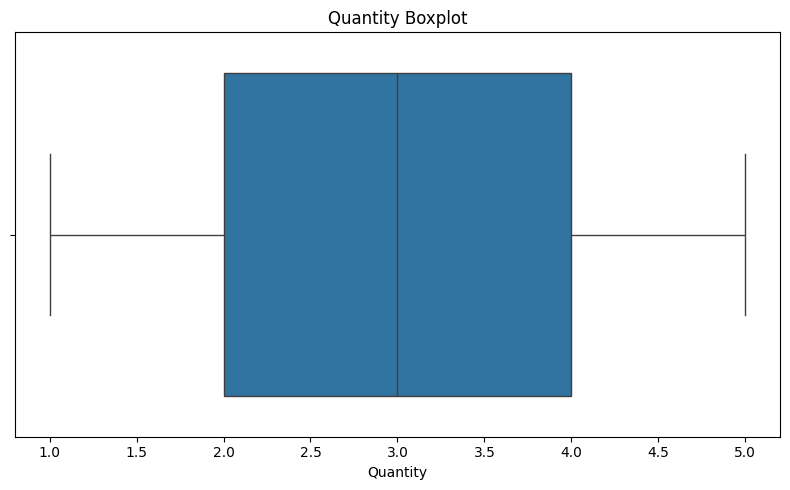

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Quantity"])

plt.title("Quantity Boxplot")
plt.xlabel("Quantity")

plt.tight_layout()
plt.savefig("../images/07_boxplot_quantity.png", dpi=300)
plt.show()

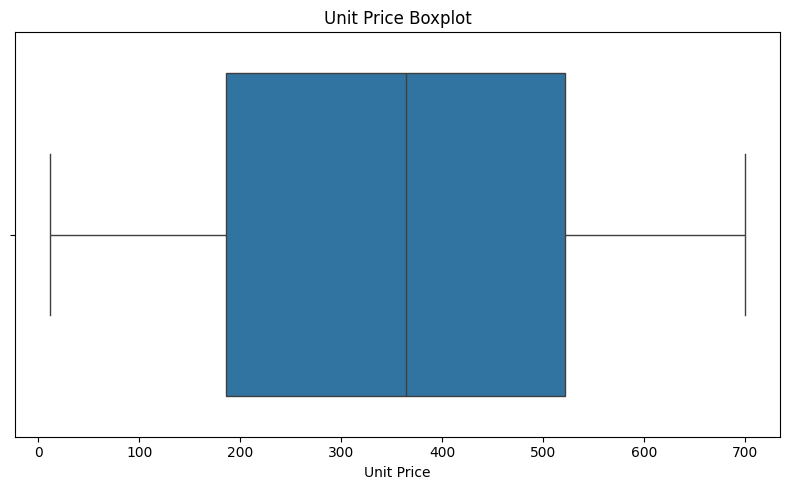

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["UnitPrice"])

plt.title("Unit Price Boxplot")
plt.xlabel("Unit Price")

plt.tight_layout()
plt.savefig("../images/08_boxplot_unit_price.png", dpi=300)
plt.show()

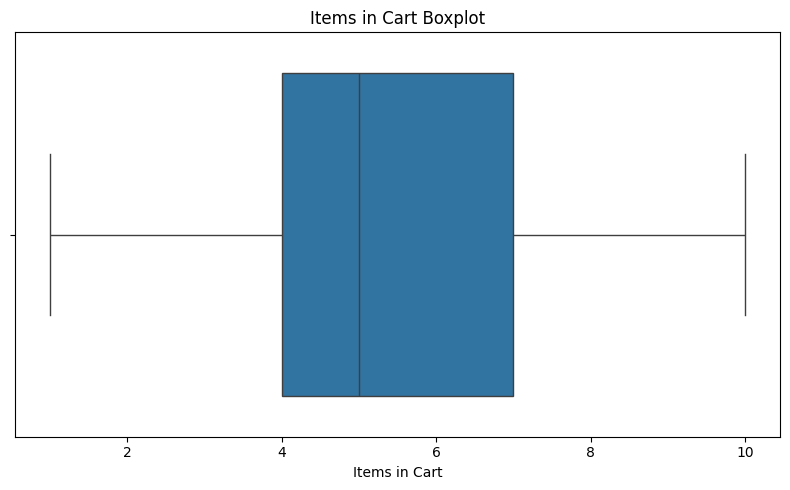

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["ItemsInCart"])

plt.title("Items in Cart Boxplot")
plt.xlabel("Items in Cart")

plt.tight_layout()
plt.savefig("../images/09_boxplot_items_in_cart.png", dpi=300)
plt.show()

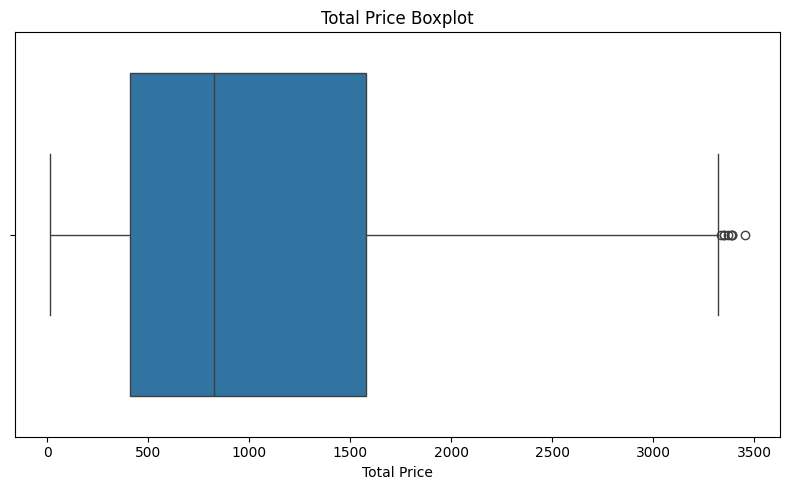

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["TotalPrice"])

plt.title("Total Price Boxplot")
plt.xlabel("Total Price")

plt.tight_layout()
plt.savefig("../images/10_boxplot_total_price.png", dpi=300)
plt.show()

### Initial Outlier Observation

The boxplots provide a visual comparison of the numerical variables and make it easier to see where unusually high or low values occur.

The variables with observations outside the main boxplot range will be investigated further before deciding whether those observations are errors or meaningful values.

## Investigating the Total Price Outliers

The IQR analysis identified eight records with unusually high `TotalPrice` values.

Before deciding whether these records should be treated as errors, I will examine their other fields and check whether the unusually high total price is supported by the transaction details.

In [35]:
total_price_outliers = df_iqr[
    df_iqr["IQR_Outlier"]
].copy()

total_price_outliers[
    [
        "OrderID",
        "Date",
        "Product",
        "Quantity",
        "UnitPrice",
        "ItemsInCart",
        "TotalPrice",
        "PaymentMethod",
        "OrderStatus",
        "CouponCode",
        "ReferralSource"
    ]
]

,OrderID,Date,Product,Quantity,UnitPrice,ItemsInCart,TotalPrice,PaymentMethod,OrderStatus,CouponCode,ReferralSource
107,ORD200107,2023-03-27,Printer,5,670.75,8,3353.75,Gift Card,Shipped,FREESHIP,Instagram
326,ORD200326,2024-07-01,Laptop,5,670.48,5,3352.40,Gift Card,Returned,SAVE10,Facebook
328,ORD200328,2023-02-28,Tablet,5,674.04,7,3370.20,Online,Cancelled,SAVE10,Google
469,ORD200469,2023-11-26,Chair,5,676.98,5,3384.90,Cash,Cancelled,NO_COUPON,Facebook
632,ORD200632,2023-05-02,Laptop,5,678.16,7,3390.80,Gift Card,Delivered,WINTER15,Facebook
789,ORD200789,2023-08-17,Tablet,5,691.28,10,3456.40,Online,Delivered,SAVE10,Email
1065,ORD201065,2023-10-30,Printer,5,666.80,7,3334.00,Debit Card,Delivered,SAVE10,Referral
1122,ORD201122,2023-06-07,Monitor,5,678.19,8,3390.95,Online,Returned,NO_COUPON,Facebook


### Outlier Value Range

The first thing to check is how far the outlier values are from the IQR upper bound.

This helps show whether these are only slightly above the normal range or substantially higher than most of the dataset.

In [36]:
outlier_value_summary = pd.DataFrame({
    "Minimum": [total_price_outliers["TotalPrice"].min()],
    "Maximum": [total_price_outliers["TotalPrice"].max()],
    "Median": [total_price_outliers["TotalPrice"].median()],
    "IQR_Upper_Bound": [iqr_summary.loc["TotalPrice", "UpperBound"]]
}).round(2)

outlier_value_summary

,Minimum,Maximum,Median,IQR_Upper_Bound
0,3334.0,3456.4,3377.55,3330.41


In [37]:
total_price_outliers["AboveIQRBound"] = (
    total_price_outliers["TotalPrice"] -
    iqr_summary.loc["TotalPrice", "UpperBound"]
)

total_price_outliers[
    [
        "OrderID",
        "Product",
        "Quantity",
        "UnitPrice",
        "TotalPrice",
        "AboveIQRBound"
    ]
].sort_values(
    "TotalPrice",
    ascending=False
).round(2)

,OrderID,Product,Quantity,UnitPrice,TotalPrice,AboveIQRBound
789,ORD200789,Tablet,5,691.28,3456.40,125.99
1122,ORD201122,Monitor,5,678.19,3390.95,60.54
632,ORD200632,Laptop,5,678.16,3390.80,60.39
469,ORD200469,Chair,5,676.98,3384.90,54.49
328,ORD200328,Tablet,5,674.04,3370.20,39.79
107,ORD200107,Printer,5,670.75,3353.75,23.34
326,ORD200326,Laptop,5,670.48,3352.40,21.99
1065,ORD201065,Printer,5,666.80,3334.00,3.59


## Checking the Outlier Calculations

A high total price could be a legitimate transaction, so I will check whether each outlier follows the expected pricing calculation:

**Expected Total Price = Quantity × Unit Price**

If the calculated value matches the recorded `TotalPrice`, the unusual value is less likely to be caused by a calculation error.

In [38]:
total_price_outliers["ExpectedTotalPrice"] = (
    total_price_outliers["Quantity"] *
    total_price_outliers["UnitPrice"]
).round(2)

total_price_outliers["PriceDifference"] = (
    total_price_outliers["TotalPrice"] -
    total_price_outliers["ExpectedTotalPrice"]
).round(2)

total_price_outliers[
    [
        "OrderID",
        "Quantity",
        "UnitPrice",
        "TotalPrice",
        "ExpectedTotalPrice",
        "PriceDifference"
    ]
]

,OrderID,Quantity,UnitPrice,TotalPrice,ExpectedTotalPrice,PriceDifference
107,ORD200107,5,670.75,3353.75,3353.75,0.0
326,ORD200326,5,670.48,3352.40,3352.40,0.0
328,ORD200328,5,674.04,3370.20,3370.20,0.0
469,ORD200469,5,676.98,3384.90,3384.90,0.0
632,ORD200632,5,678.16,3390.80,3390.80,0.0
789,ORD200789,5,691.28,3456.40,3456.40,0.0
1065,ORD201065,5,666.80,3334.00,3334.00,0.0
1122,ORD201122,5,678.19,3390.95,3390.95,0.0


In [39]:
total_price_outliers["CalculationCheck"] = (
    total_price_outliers["PriceDifference"] == 0
)

total_price_outliers[
    [
        "OrderID",
        "TotalPrice",
        "ExpectedTotalPrice",
        "PriceDifference",
        "CalculationCheck"
    ]
]

,OrderID,TotalPrice,ExpectedTotalPrice,PriceDifference,CalculationCheck
107,ORD200107,3353.75,3353.75,0.0,True
326,ORD200326,3352.40,3352.40,0.0,True
328,ORD200328,3370.20,3370.20,0.0,True
469,ORD200469,3384.90,3384.90,0.0,True
632,ORD200632,3390.80,3390.80,0.0,True
789,ORD200789,3456.40,3456.40,0.0,True
1065,ORD201065,3334.00,3334.00,0.0,True
1122,ORD201122,3390.95,3390.95,0.0,True


### Calculation Check

The calculation check shows whether the recorded `TotalPrice` agrees with the quantity and unit price.

A matching calculation suggests that the unusual total price is not caused by an arithmetic or pricing inconsistency in the record.

The outliers will therefore be evaluated based on their transaction characteristics rather than being removed simply because they are statistically unusual.

## Looking for Common Patterns in the Outliers

The next step is to compare the outlier records by product, quantity, order status, payment method, and referral source.

This can help show whether the unusual transactions are random or whether they are concentrated around a particular type of order.

In [40]:
product_outliers = (
    total_price_outliers["Product"]
    .value_counts()
    .rename("OutlierCount")
    .to_frame()
)

product_outliers

,OutlierCount
Product,
Printer,2
Laptop,2
Tablet,2
Chair,1
Monitor,1


In [41]:
quantity_outliers = (
    total_price_outliers["Quantity"]
    .value_counts()
    .sort_index()
    .rename("OutlierCount")
    .to_frame()
)

quantity_outliers

,OutlierCount
Quantity,
5,8


In [42]:
status_outliers = (
    total_price_outliers["OrderStatus"]
    .value_counts()
    .rename("OutlierCount")
    .to_frame()
)

status_outliers

,OutlierCount
OrderStatus,
Delivered,3
Returned,2
Cancelled,2
Shipped,1


In [43]:
payment_outliers = (
    total_price_outliers["PaymentMethod"]
    .value_counts()
    .rename("OutlierCount")
    .to_frame()
)

payment_outliers

,OutlierCount
PaymentMethod,
Gift Card,3
Online,3
Cash,1
Debit Card,1


In [44]:
referral_outliers = (
    total_price_outliers["ReferralSource"]
    .value_counts()
    .rename("OutlierCount")
    .to_frame()
)

referral_outliers

,OutlierCount
ReferralSource,
Facebook,4
Instagram,1
Google,1
Email,1
Referral,1


## Comparing Outliers with the Full Dataset

The outlier records will be compared with the full dataset to see whether some products or categories appear more often among the unusual transactions.

This helps distinguish an actual concentration from a pattern that occurs simply because that product is common in the dataset.

In [45]:
overall_product_share = (
    df["Product"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("OverallPercentage")
)

outlier_product_share = (
    total_price_outliers["Product"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("OutlierPercentage")
)

product_comparison = pd.concat(
    [
        overall_product_share,
        outlier_product_share
    ],
    axis=1
).fillna(0)

product_comparison

,OverallPercentage,OutlierPercentage
Product,,
Printer,15.08,25.0
Tablet,14.92,25.0
Chair,14.83,12.5
Laptop,14.42,25.0
Desk,14.17,0.0
Monitor,13.58,12.5
Phone,13.00,0.0


In [46]:
comparison_summary = pd.DataFrame({
    "FullDataset_Mean": df[
        ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
    ].mean(),
    
    "Outlier_Mean": total_price_outliers[
        ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
    ].mean()
}).round(2)

comparison_summary

,FullDataset_Mean,Outlier_Mean
Quantity,2.95,5.00
UnitPrice,356.41,675.84
ItemsInCart,5.48,7.12
TotalPrice,1053.97,3379.18


### Outlier Comparison

The comparison with the full dataset shows which characteristics of the outlier records differ most from the typical transaction.

A useful distinction here is that an outlier can be unusual without being incorrect. If the records have valid calculations and their high values are explained by higher quantities or unit prices, they may represent genuine high-value transactions rather than data-quality problems.

## IQR Outlier Conclusion

The IQR method identified eight potential outliers in `TotalPrice`, representing 0.67% of the dataset. No IQR outliers were found for `Quantity`, `UnitPrice`, or `ItemsInCart`.

The flagged records will be considered valid observations when their transaction values are consistent with the expected pricing calculation and there is no evidence of a data-entry or calculation error.

Because an outlier can represent a legitimate high-value transaction, the records will not be removed solely because they fall outside the IQR range.

## Identifying Outliers Using Z-Score

The IQR method has already identified unusual values in the dataset.

To compare the result with another method, Z-scores will also be calculated for the numerical variables.

A Z-score shows how far a value is from the mean in terms of standard deviations.

For this analysis, values with a Z-score greater than 3 or less than -3 will be flagged as potential outliers.

### Calculating Z-Scores

The Z-score will be calculated for each value in the four numerical variables.

The result will show whether any observations are unusually far from the average compared with the rest of the dataset.

In [47]:
from scipy.stats import zscore

In [48]:
z_scores = df[numeric_columns].apply(zscore)

z_scores.round(2).head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,1.46,1.09,0.66,2.20
1,-0.67,-1.04,-1.09,-0.92
2,1.46,0.99,1.10,2.07
3,-1.38,-0.42,-0.21,-0.95
4,0.75,1.37,1.10,1.77


### Flagging Z-Score Outliers

A record will be flagged when its absolute Z-score is greater than 3.

This means the value is more than three standard deviations away from the mean.

In [49]:
z_outlier_counts = {}

for column in numeric_columns:
    z_outlier_counts[column] = (
        z_scores[column].abs() > 3
    ).sum()

z_outlier_counts = pd.Series(
    z_outlier_counts,
    name="ZScoreOutlierCount"
)

z_outlier_counts

Quantity       0
UnitPrice      0
ItemsInCart    0
TotalPrice     0
Name: ZScoreOutlierCount, dtype: int64

In [50]:
z_outlier_percentage = (
    z_outlier_counts / len(df) * 100
).round(2)

zscore_outlier_summary = pd.DataFrame({
    "OutlierCount": z_outlier_counts,
    "OutlierPercentage": z_outlier_percentage
})

zscore_outlier_summary

,OutlierCount,OutlierPercentage
Quantity,0,0.0
UnitPrice,0,0.0
ItemsInCart,0,0.0
TotalPrice,0,0.0


### Z-Score Results

The Z-score results show whether any of the numerical variables contain observations that are more than three standard deviations away from their mean.

These results will be compared with the IQR findings to see whether both methods identify similar unusual observations.

In [51]:
df_zscore = df.copy()

df_zscore["ZScore_Outlier"] = False

for column in numeric_columns:
    column_outlier = z_scores[column].abs() > 3
    
    df_zscore["ZScore_Outlier"] = (
        df_zscore["ZScore_Outlier"] |
        column_outlier
    )

zscore_records = df_zscore[
    df_zscore["ZScore_Outlier"]
]

zscore_records

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,ZScore_Outlier


### Comparing IQR and Z-Score Results

The two methods identify unusual observations using different approaches.

The IQR method is based on the middle 50% of the data, while the Z-score method measures distance from the mean.

Comparing the results helps show whether the unusual values identified by IQR are also extreme relative to the overall distribution.

In [52]:
outlier_method_comparison = pd.DataFrame({
    "IQR_Outliers": outlier_counts,
    "ZScore_Outliers": z_outlier_counts
})

outlier_method_comparison

,IQR_Outliers,ZScore_Outliers
Quantity,0,0
UnitPrice,0,0
ItemsInCart,0,0
TotalPrice,8,0


### Outlier Method Observation

The comparison shows whether the IQR and Z-score methods produce the same result for each numerical variable.

A difference between the two methods does not automatically mean that one method is wrong. The methods use different definitions of what makes a value unusual, so the results need to be interpreted in the context of the data.

## Comparing the IQR Outliers with Z-Scores

The IQR method identified eight records with unusually high `TotalPrice`, while the Z-score method did not flag any records.

To understand the difference between the two methods, the Z-scores of the IQR-flagged records will be examined.

This will show how far these records are from the overall mean and why they were flagged by one method but not the other.

In [53]:
iqr_outlier_zscores = z_scores.loc[
    total_price_outliers.index,
    numeric_columns
].copy()

iqr_outlier_zscores

,Quantity,UnitPrice,ItemsInCart,TotalPrice
107,1.459993,1.594852,1.102571,2.806272
326,1.459993,1.593482,-0.212623,2.804625
328,1.459993,1.611544,0.664173,2.826345
469,1.459993,1.626461,-0.212623,2.844282
632,1.459993,1.632448,0.664173,2.851482
789,1.459993,1.699015,1.979367,2.931529
1065,1.459993,1.574811,0.664173,2.782172
1122,1.459993,1.632600,1.102571,2.851665


In [54]:
iqr_totalprice_zscores = pd.DataFrame({
    "OrderID": total_price_outliers["OrderID"],
    "TotalPrice": total_price_outliers["TotalPrice"],
    "TotalPrice_ZScore": z_scores.loc[
        total_price_outliers.index,
        "TotalPrice"
    ]
})

iqr_totalprice_zscores.sort_values(
    "TotalPrice_ZScore",
    ascending=False
).round(2)

,OrderID,TotalPrice,TotalPrice_ZScore
789,ORD200789,3456.40,2.93
1122,ORD201122,3390.95,2.85
632,ORD200632,3390.80,2.85
469,ORD200469,3384.90,2.84
328,ORD200328,3370.20,2.83
107,ORD200107,3353.75,2.81
326,ORD200326,3352.40,2.80
1065,ORD201065,3334.00,2.78


### Z-Score Range of the IQR Outliers

The IQR-flagged records can still have relatively moderate Z-scores.

If their Z-scores remain below 3, they are unusual according to the IQR definition but are not extreme enough to be classified as Z-score outliers under the threshold used in this analysis.

In [55]:
iqr_zscore_summary = pd.DataFrame({
    "Minimum_ZScore": [
        iqr_totalprice_zscores["TotalPrice_ZScore"].min()
    ],
    "Maximum_ZScore": [
        iqr_totalprice_zscores["TotalPrice_ZScore"].max()
    ],
    "Mean_ZScore": [
        iqr_totalprice_zscores["TotalPrice_ZScore"].mean()
    ]
}).round(2)

iqr_zscore_summary

,Minimum_ZScore,Maximum_ZScore,Mean_ZScore
0,2.78,2.93,2.84


### IQR and Z-Score Comparison

The IQR method focuses on the spread of the middle 50% of the data, while the Z-score method measures distance from the mean.

Because the two methods use different definitions of an unusual value, it is possible for IQR to flag records that do not cross the Z-score threshold.

The results from this dataset will be used to explain which method is more sensitive to the high `TotalPrice` values.

In [56]:
final_outlier_comparison = pd.DataFrame({
    "IQR_Outliers": outlier_counts,
    "IQR_Percentage": (
        outlier_counts / len(df) * 100
    ).round(2),
    "ZScore_Outliers": z_outlier_counts,
    "ZScore_Percentage": (
        z_outlier_counts / len(df) * 100
    ).round(2)
})

final_outlier_comparison

,IQR_Outliers,IQR_Percentage,ZScore_Outliers,ZScore_Percentage
Quantity,0,0.00,0,0.0
UnitPrice,0,0.00,0,0.0
ItemsInCart,0,0.00,0,0.0
TotalPrice,8,0.67,0,0.0


### Largest Absolute Z-Score

Although no observations crossed the Z-score threshold of 3, it is still useful to see the largest absolute Z-score for each numerical variable.

This helps show how close the most unusual values came to the chosen threshold.

In [57]:
largest_zscore = pd.DataFrame({
    "LargestAbsoluteZScore": z_scores[
        numeric_columns
    ].abs().max()
}).round(2)

largest_zscore

,LargestAbsoluteZScore
Quantity,1.46
UnitPrice,1.75
ItemsInCart,1.98
TotalPrice,2.93


### Z-Score Observation

The largest absolute Z-scores remain below the threshold of 3 used in this analysis.

This means the dataset does not contain observations that are extremely far from the mean according to the Z-score method.

The IQR method is more sensitive here and identifies eight high `TotalPrice` observations that are unusual relative to the middle 50% of the data.

## Key Trend Findings

The monthly analysis shows that order activity and total sales fluctuate throughout the period rather than following one consistent upward or downward trend.

The highest and lowest months provide useful points for understanding where activity was strongest and weakest.

In [58]:
trend_findings = pd.DataFrame({
    "Measure": [
        "Highest Orders",
        "Lowest Orders",
        "Highest Total Sales",
        "Lowest Total Sales",
        "Highest Sales per Order",
        "Lowest Sales per Order"
    ],
    "Date": [
        highest_orders["Date"],
        lowest_orders["Date"],
        highest_sales["Date"],
        lowest_sales["Date"],
        highest_sales_per_order["Date"],
        lowest_sales_per_order["Date"]
    ],
    "Value": [
        highest_orders["Orders"],
        lowest_orders["Orders"],
        highest_sales["TotalSales"],
        lowest_sales["TotalSales"],
        highest_sales_per_order["SalesPerOrder"],
        lowest_sales_per_order["SalesPerOrder"]
    ]
})

trend_findings

,Measure,Date,Value
0,Highest Orders,2024-06-30,53.000000
1,Lowest Orders,2025-01-31,27.000000
2,Highest Total Sales,2024-06-30,68068.540000
3,Lowest Total Sales,2023-04-30,27751.710000
4,Highest Sales per Order,2023-05-31,1302.792653
5,Lowest Sales per Order,2025-03-31,800.013469


### Trend Observation

The strongest order activity occurred in June 2024 with 53 orders, while the lowest order activity occurred in January 2025 with 27 orders.

June 2024 also recorded the highest monthly total sales at 68,068.54. The lowest monthly total sales occurred in April 2023 at 27,751.71.

The largest month-to-month increase in total sales occurred in June 2024, while the largest decrease occurred in September 2023.

These results show that the dataset contains noticeable monthly fluctuations rather than a steady trend across the full period.

## Key Outlier Findings

The IQR method identified eight unusual records in `TotalPrice`.

No potential outliers were found for `Quantity`, `UnitPrice`, or `ItemsInCart`.

The eight flagged records represent only 0.67% of the dataset, so the unusual values are limited to a small part of the data.

In [59]:
outlier_evidence = total_price_outliers[
    [
        "OrderID",
        "Product",
        "Quantity",
        "UnitPrice",
        "TotalPrice",
        "ExpectedTotalPrice",
        "PriceDifference",
        "CalculationCheck"
    ]
].copy()

outlier_evidence = outlier_evidence.sort_values(
    "TotalPrice",
    ascending=False
)

outlier_evidence.round(2)

,OrderID,Product,Quantity,UnitPrice,TotalPrice,ExpectedTotalPrice,PriceDifference,CalculationCheck
789,ORD200789,Tablet,5,691.28,3456.40,3456.40,0.0,True
1122,ORD201122,Monitor,5,678.19,3390.95,3390.95,0.0,True
632,ORD200632,Laptop,5,678.16,3390.80,3390.80,0.0,True
469,ORD200469,Chair,5,676.98,3384.90,3384.90,0.0,True
328,ORD200328,Tablet,5,674.04,3370.20,3370.20,0.0,True
107,ORD200107,Printer,5,670.75,3353.75,3353.75,0.0,True
326,ORD200326,Laptop,5,670.48,3352.40,3352.40,0.0,True
1065,ORD201065,Printer,5,666.80,3334.00,3334.00,0.0,True


### Outlier Investigation Result

The eight `TotalPrice` outliers all have a quantity of 5 and relatively high unit prices.

Their recorded `TotalPrice` values match the expected calculation of `Quantity × UnitPrice`, with no difference between the recorded and expected values.

The outliers are also spread across several products and different transaction characteristics rather than being concentrated in one obvious data-quality issue.

Based on these checks, the records appear to represent unusually high-value orders rather than calculation errors.

## Decision on the Identified Outliers

The eight `TotalPrice` outliers will be retained in the dataset.

They are unusual according to the IQR method, but the investigation did not find evidence of a calculation or pricing inconsistency.

The records appear to represent legitimate high-value transactions rather than obvious data errors.

For this reason, the outliers will be retained for the remaining analysis while still being noted as unusual observations.

In [60]:
print("Original dataset records:", len(df))
print("IQR outlier records:", int(total_iqr_records))
print("Records remaining if outliers are retained:", len(df))

Original dataset records: 1200
IQR outlier records: 8
Records remaining if outliers are retained: 1200


### Outlier Handling

The original 1,200 records are retained.

The outliers are not removed because the investigation suggests that they are legitimate high-value transactions rather than data errors.

They will remain available for later analysis so that the final findings are based on the complete dataset.

## Task 3 Summary

The trend analysis showed noticeable changes in monthly order activity and total sales across the dataset.

June 2024 had the highest number of orders and the highest total sales, while January 2025 had the lowest order count and April 2023 had the lowest total sales.

The IQR method identified eight unusual `TotalPrice` records, representing 0.67% of the dataset. No outliers were found for `Quantity`, `UnitPrice`, or `ItemsInCart`.

The eight `TotalPrice` records were investigated further. Their total prices were supported by their quantities and unit prices, and all eight passed the pricing calculation check.

The Z-score method identified no observations above the threshold of 3. The IQR-identified records had TotalPrice Z-scores between 2.78 and 2.93.

Based on the available evidence, the eight unusual records will be retained as valid high-value transactions rather than removed as errors.

This completes the trends and outlier analysis for Task 3.

## Task 4: Relationships and Correlation

In this part of the analysis, I want to understand how the numerical variables in the dataset relate to each other.

So far, I have looked at individual variables, their distributions, monthly trends and unusual values. Now I want to see whether some variables tend to change together.

I will use Pearson correlation to measure the direction and strength of linear relationships between numerical variables. I will also use charts to help me understand the results rather than relying only on correlation values.

### What I want to find out

I will focus on four numerical variables:

- `Quantity` — the number of units purchased.
- `UnitPrice` — the price of one unit.
- `ItemsInCart` — the number of items in the cart.
- `TotalPrice` — the total price of the order.

The main questions I want to investigate are:

1. Is there a relationship between quantity purchased and total price?
2. Does unit price have a relationship with total price?
3. Are the number of items in the cart and the total price related?
4. Are there any other noticeable relationships between these variables?

I will use the results to identify patterns worth investigating further. A correlation can show that two variables move together, but it does not prove that one variable causes the other.

### Preparing the Data

Before calculating correlations, I will check that the four selected variables are available, contain numeric values and do not have missing data that could affect the results.

I will also check the data types and the number of records available for the analysis. This will help me understand whether any preparation is needed before calculating Pearson correlation.

In [61]:
# Select the numerical variables for correlation analysis

correlation_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

correlation_df = df[correlation_columns].copy()

# Check the size of the selected data
print("Number of records:", correlation_df.shape[0])
print("Number of selected variables:", correlation_df.shape[1])

# Check data types
print("\nData types:")
display(correlation_df.dtypes.to_frame(name="Data Type"))

# Check missing values
print("\nMissing values:")
display(correlation_df.isnull().sum().to_frame(name="Missing Values"))

# Check for non-numeric values after selection
print("\nNumeric column check:")
display(correlation_df.select_dtypes(include="number").columns.to_list())

Number of records: 1200
Number of selected variables: 4

Data types:


,Data Type
Quantity,int64
UnitPrice,float64
ItemsInCart,int64
TotalPrice,float64



Missing values:


,Missing Values
Quantity,0
UnitPrice,0
ItemsInCart,0
TotalPrice,0



Numeric column check:


['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

### Initial Data Check

The checks above show whether the selected variables are ready for correlation analysis.

I will use the results to confirm the number of records, check for missing values and make sure all four variables have numeric data types before moving on to Pearson correlation.

### Calculating Pearson Correlation

Now that the selected data has been checked, I can calculate Pearson correlation between the numerical variables.

Pearson correlation measures the direction and strength of a linear relationship between two variables. Its value ranges from -1 to +1.

- A value close to +1 indicates a strong positive linear relationship.
- A value close to -1 indicates a strong negative linear relationship.
- A value close to 0 indicates little or no linear relationship.

A correlation value alone does not explain why a relationship exists, so I will interpret the results alongside the charts in the next part of the analysis.

In [62]:
# Calculate Pearson correlation between the selected variables

correlation_matrix = correlation_df.corr(method="pearson")

# Display the correlation matrix
display(correlation_matrix.round(3))

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000,0.015,0.650,0.615
UnitPrice,0.015,1.000,0.001,0.717
ItemsInCart,0.650,0.001,1.000,0.393
TotalPrice,0.615,0.717,0.393,1.000


In [63]:
# Extract each unique pair of variables

correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        variable_1 = correlation_matrix.columns[i]
        variable_2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]

        correlation_pairs.append({
            "Variable 1": variable_1,
            "Variable 2": variable_2,
            "Pearson Correlation": correlation_value
        })

correlation_pairs_df = pd.DataFrame(correlation_pairs)

# Sort relationships by absolute correlation strength
correlation_pairs_df["Absolute Correlation"] = (
    correlation_pairs_df["Pearson Correlation"].abs()
)

correlation_pairs_df = correlation_pairs_df.sort_values(
    by="Absolute Correlation",
    ascending=False
).drop(columns="Absolute Correlation")

display(
    correlation_pairs_df.round(3).reset_index(drop=True)
)

,Variable 1,Variable 2,Pearson Correlation
0,UnitPrice,TotalPrice,0.717
1,Quantity,ItemsInCart,0.650
2,Quantity,TotalPrice,0.615
3,ItemsInCart,TotalPrice,0.393
4,Quantity,UnitPrice,0.015
5,UnitPrice,ItemsInCart,0.001


### First Look at the Correlation Results

The correlation matrix shows how strongly each pair of variables is linearly related. I will use the table of unique pairs to identify which relationships are strongest and which are weaker.

At this stage, these values are measurements of association rather than proof of cause and effect. I will examine the charts before drawing conclusions about the patterns in the dataset.

### Visualising the Correlations

The correlation values give me a useful summary, but I also want to see how the variables are distributed against each other.

I will start with a heatmap to compare all the correlations at once. Then I will use scatter plots to look more closely at selected relationships, especially those involving TotalPrice.

These charts will help me check whether the relationships look reasonably linear and whether unusual observations affect the overall pattern.

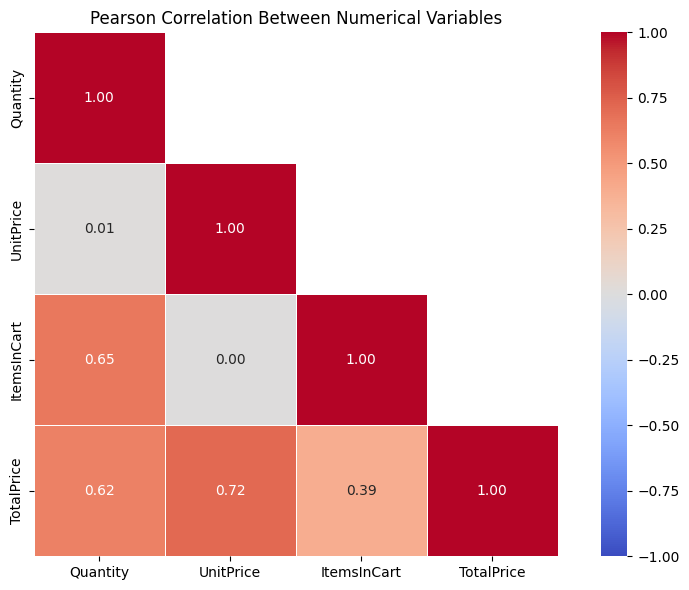

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hide the upper triangle to avoid repeating correlations
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool),
    k=1
)

# Create the correlation heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Between Numerical Variables")
plt.tight_layout()

# Save the chart
plt.savefig(
    "../images/11_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

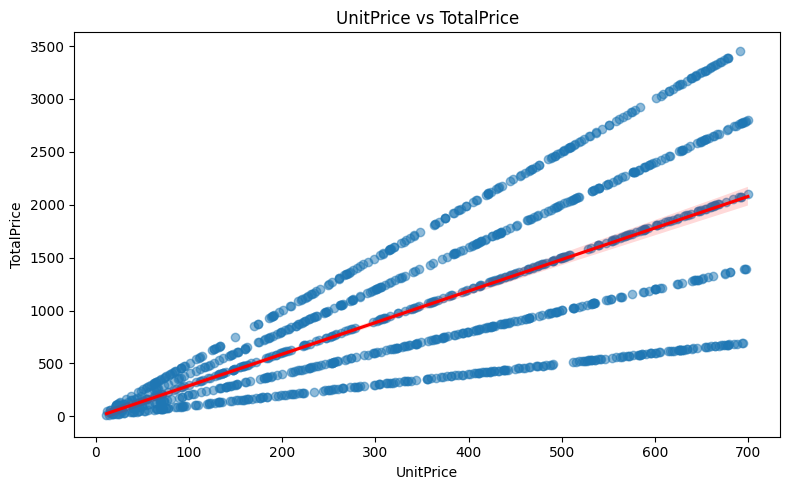

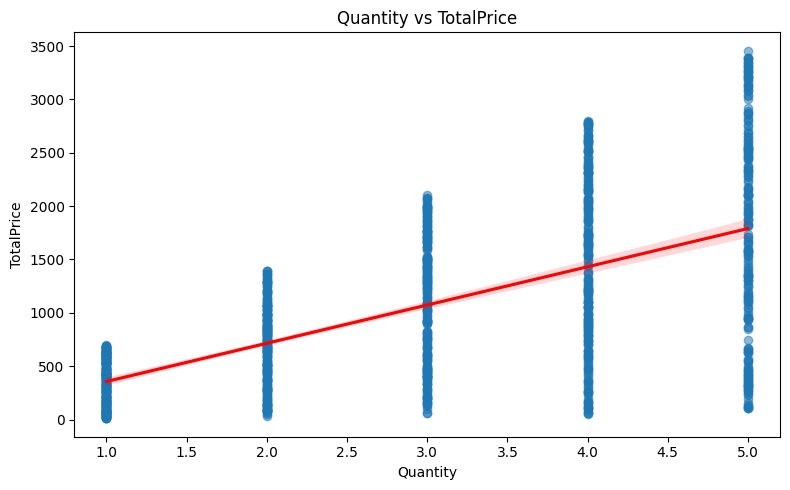

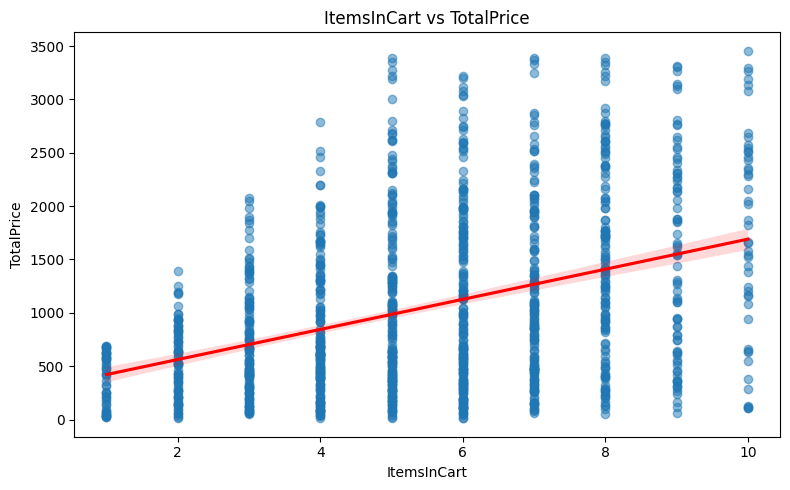

In [65]:
# Relationships to examine more closely
scatter_pairs = [
    ("UnitPrice", "TotalPrice"),
    ("Quantity", "TotalPrice"),
    ("ItemsInCart", "TotalPrice")
]

for i, (x_column, y_column) in enumerate(scatter_pairs, start=12):
    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=correlation_df,
        x=x_column,
        y=y_column,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )

    plt.title(f"{x_column} vs {y_column}")
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.tight_layout()

    filename = (
        f"../images/{i}_{x_column.lower()}_vs_"
        f"{y_column.lower()}.png"
    )

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

### What the Correlations Tell Me

The strongest positive correlation in the results is between `UnitPrice` and `TotalPrice`, with a Pearson correlation of 0.717. This means that higher unit prices tend to be associated with higher total prices in this dataset.

There is also a positive relationship between `Quantity` and `ItemsInCart`, with a correlation of 0.650. The relationship between `Quantity` and `TotalPrice` is positive as well, with a correlation of 0.615.

`ItemsInCart` and `TotalPrice` have a weaker positive correlation of 0.393. This suggests that the number of items in the cart is less closely related to total price than unit price or quantity in this dataset.

The correlations between `Quantity` and `UnitPrice` (0.015), and between `UnitPrice` and `ItemsInCart` (0.001), are very close to zero. This indicates little or no linear relationship between these pairs.

One important point is that `TotalPrice` is calculated using `Quantity × UnitPrice`. Therefore, its positive relationships with quantity and unit price must be interpreted in the context of how the dataset is constructed. Correlation does not prove causation, and these results alone cannot explain why the relationships exist.

### Comparing the Strength of Relationships

The correlation matrix gives me a value for every pair of numerical variables. To make the results easier to explain, I will group the correlations into broad categories based on their absolute values.

These categories are only guidelines. A correlation should not be judged by its number alone; the context of the variables and the scatter plots also matter.

In [66]:
def describe_correlation(value):
    """Describe the strength and direction of a Pearson correlation."""

    strength = abs(value)

    if strength < 0.10:
        strength_label = "Very weak"
    elif strength < 0.30:
        strength_label = "Weak"
    elif strength < 0.50:
        strength_label = "Moderate"
    elif strength < 0.70:
        strength_label = "Strong"
    else:
        strength_label = "Very strong"

    if value > 0:
        direction = "Positive"
    elif value < 0:
        direction = "Negative"
    else:
        direction = "No direction"

    return f"{strength_label} {direction.lower()}"

In [67]:
correlation_interpretation = correlation_pairs_df.copy()

correlation_interpretation["Strength and Direction"] = (
    correlation_interpretation["Pearson Correlation"]
    .apply(describe_correlation)
)

display(
    correlation_interpretation.round(
        {"Pearson Correlation": 3}
    )
)

,Variable 1,Variable 2,Pearson Correlation,Strength and Direction
4,UnitPrice,TotalPrice,0.717,Very strong positive
1,Quantity,ItemsInCart,0.650,Strong positive
2,Quantity,TotalPrice,0.615,Strong positive
5,ItemsInCart,TotalPrice,0.393,Moderate positive
0,Quantity,UnitPrice,0.015,Very weak positive
3,UnitPrice,ItemsInCart,0.001,Very weak positive


### What the Strength Labels Mean

The labels provide a quick way to compare the relationships, but they do not explain the reason behind them.

A positive correlation means that higher values of one variable tend to occur alongside higher values of the other. A negative correlation means that higher values of one variable tend to occur alongside lower values of the other.

A correlation close to zero means that there is little linear association. It does not rule out every possible type of relationship between the variables.

### Checking the TotalPrice Calculation

Before interpreting the relationships involving `TotalPrice`, I will check its calculation against `Quantity × UnitPrice`.

This check matters because a mathematical relationship built into the dataset can help explain why two variables are correlated. It does not, by itself, establish a separate business cause.

In [68]:
# Recalculate TotalPrice from Quantity and UnitPrice
correlation_df["CalculatedTotalPrice"] = (
    correlation_df["Quantity"] * correlation_df["UnitPrice"]
)

# Compare the calculated and recorded values
correlation_df["PriceDifference"] = (
    correlation_df["TotalPrice"]
    - correlation_df["CalculatedTotalPrice"]
).round(2)

# Summarise the check
price_check_summary = pd.DataFrame({
    "Measure": [
        "Records checked",
        "Exact matches after rounding to 2 decimals",
        "Records with a difference",
        "Largest absolute difference"
    ],
    "Result": [
        len(correlation_df),
        int((correlation_df["PriceDifference"] == 0).sum()),
        int((correlation_df["PriceDifference"] != 0).sum()),
        correlation_df["PriceDifference"].abs().max()
    ]
})

display(price_check_summary)

,Measure,Result
0,Records checked,1200.0
1,Exact matches after rounding to 2 decimals,1200.0
2,Records with a difference,0.0
3,Largest absolute difference,0.0


In [69]:
price_check_issues = correlation_df.loc[
    correlation_df["PriceDifference"] != 0,
    [
        "Quantity",
        "UnitPrice",
        "TotalPrice",
        "CalculatedTotalPrice",
        "PriceDifference"
    ]
]

print("Number of calculation differences:", len(price_check_issues))

display(price_check_issues.head(10))

Number of calculation differences: 0


,Quantity,UnitPrice,TotalPrice,CalculatedTotalPrice,PriceDifference


### Interpreting the Calculation Check

I will use the results above to determine whether the recorded total prices agree with the values calculated from quantity and unit price.

If the values match, that supports the consistency of this calculation in the dataset. If any differences appear, I will investigate them before drawing conclusions from the correlations involving `TotalPrice`.

### Checking the Effect of High-Value Transactions

The earlier outlier analysis identified eight unusually high `TotalPrice` records. These were retained because the investigation did not identify obvious calculation errors.

I will compare the correlations calculated using all records with the correlations calculated after temporarily excluding those eight records. This is a sensitivity check: it helps show whether the observed relationships depend heavily on a small number of high-value transactions.

The full dataset remains unchanged, and the original correlations will still be reported as the main results.

In [70]:
# Calculate the IQR limits for TotalPrice
total_price_q1 = correlation_df["TotalPrice"].quantile(0.25)
total_price_q3 = correlation_df["TotalPrice"].quantile(0.75)

total_price_iqr = total_price_q3 - total_price_q1

total_price_lower_bound = total_price_q1 - 1.5 * total_price_iqr
total_price_upper_bound = total_price_q3 + 1.5 * total_price_iqr

# Identify the records outside the IQR limits
total_price_outlier_mask = (
    (correlation_df["TotalPrice"] < total_price_lower_bound)
    | (correlation_df["TotalPrice"] > total_price_upper_bound)
)

print("TotalPrice lower bound:", round(total_price_lower_bound, 2))
print("TotalPrice upper bound:", round(total_price_upper_bound, 2))
print("Records flagged by the IQR method:", int(total_price_outlier_mask.sum()))

# Keep the non-outlier records for comparison only
correlation_without_outliers = correlation_df.loc[
    ~total_price_outlier_mask,
    correlation_columns
].copy()

print("Records in comparison dataset:", len(correlation_without_outliers))

TotalPrice lower bound: -1341.41
TotalPrice upper bound: 3330.41
Records flagged by the IQR method: 8
Records in comparison dataset: 1192


In [71]:
# Compare correlations using all records and the sensitivity-check dataset
correlation_all = correlation_df[correlation_columns].corr(method="pearson")

correlation_without = correlation_without_outliers.corr(
    method="pearson"
)

correlation_comparison = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):
        variable_1 = correlation_columns[i]
        variable_2 = correlation_columns[j]

        full_value = correlation_all.loc[variable_1, variable_2]
        comparison_value = correlation_without.loc[variable_1, variable_2]

        correlation_comparison.append({
            "Variable 1": variable_1,
            "Variable 2": variable_2,
            "All Records": full_value,
            "Without TotalPrice Outliers": comparison_value,
            "Change": comparison_value - full_value
        })

correlation_comparison_df = pd.DataFrame(correlation_comparison)

display(
    correlation_comparison_df.round(3)
)

,Variable 1,Variable 2,All Records,Without TotalPrice Outliers,Change
0,Quantity,UnitPrice,0.015,-0.001,-0.016
1,Quantity,ItemsInCart,0.650,0.650,-0.000
2,Quantity,TotalPrice,0.615,0.608,-0.007
3,UnitPrice,ItemsInCart,0.001,-0.007,-0.008
4,UnitPrice,TotalPrice,0.717,0.712,-0.005
5,ItemsInCart,TotalPrice,0.393,0.391,-0.002


### Interpreting the Sensitivity Check

I will compare the correlation values from the full dataset with those from the temporary comparison dataset.

Small changes would suggest that the relationships are relatively stable when these high-value records are excluded. Larger changes would suggest that the records have a noticeable influence on some relationships.

This comparison does not mean the outliers should be removed. Their treatment should depend on the data checks and business context established in the earlier analysis.

### Testing the Statistical Significance of Correlations

Pearson correlation tells me the direction and strength of a linear relationship. I can also calculate a p-value to assess whether the observed correlation is inconsistent with a population correlation of zero, under the assumptions of the test.

I will test each unique pair of numerical variables using the Pearson correlation test. I will use a 5% significance level for this analysis.

A small p-value does not mean the relationship is strong or important in practice. I will consider the correlation value and the business context alongside the p-value.

In [72]:
from scipy.stats import pearsonr

significance_level = 0.05

pearson_test_results = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):
        variable_1 = correlation_columns[i]
        variable_2 = correlation_columns[j]

        x = correlation_df[variable_1]
        y = correlation_df[variable_2]

        correlation_value, p_value = pearsonr(x, y)

        pearson_test_results.append({
            "Variable 1": variable_1,
            "Variable 2": variable_2,
            "Pearson Correlation": correlation_value,
            "P-value": p_value
        })

pearson_test_df = pd.DataFrame(pearson_test_results)

display(pearson_test_df.round(5))

,Variable 1,Variable 2,Pearson Correlation,P-value
0,Quantity,UnitPrice,0.01455,0.61451
1,Quantity,ItemsInCart,0.65006,0.00000
2,Quantity,TotalPrice,0.61525,0.00000
3,UnitPrice,ItemsInCart,0.00060,0.98338
4,UnitPrice,TotalPrice,0.71708,0.00000
5,ItemsInCart,TotalPrice,0.39254,0.00000


### Understanding the P-values

For each pair, the p-value helps me assess the evidence against the null hypothesis that the population Pearson correlation is zero.

- If the p-value is below 0.05, I will classify the result as statistically significant at the chosen level.
- If the p-value is 0.05 or higher, I will not classify it as statistically significant at that level.

These results depend on the assumptions of the Pearson correlation test. Statistical significance alone does not establish causation or practical importance.

In [73]:
pearson_test_df["Statistically Significant"] = (
    pearson_test_df["P-value"] < significance_level
)

pearson_test_df["Result at 5% Level"] = pearson_test_df[
    "Statistically Significant"
].map({
    True: "Statistically significant",
    False: "Not statistically significant"
})

display(
    pearson_test_df[
        [
            "Variable 1",
            "Variable 2",
            "Pearson Correlation",
            "P-value",
            "Result at 5% Level"
        ]
    ].round(5)
)

,Variable 1,Variable 2,Pearson Correlation,P-value,Result at 5% Level
0,Quantity,UnitPrice,0.01455,0.61451,Not statistically significant
1,Quantity,ItemsInCart,0.65006,0.00000,Statistically significant
2,Quantity,TotalPrice,0.61525,0.00000,Statistically significant
3,UnitPrice,ItemsInCart,0.00060,0.98338,Not statistically significant
4,UnitPrice,TotalPrice,0.71708,0.00000,Statistically significant
5,ItemsInCart,TotalPrice,0.39254,0.00000,Statistically significant


### Comparing Strength with Statistical Significance

I will compare the strength of each correlation with its statistical significance.

A relationship can be statistically significant but still have a weak correlation. This is especially worth remembering when analysing a dataset with many records.

For this reason, I will not use p-values alone to decide which relationships deserve the most attention.

In [74]:
correlation_results_summary = correlation_interpretation.merge(
    pearson_test_df[
        [
            "Variable 1",
            "Variable 2",
            "P-value",
            "Statistically Significant"
        ]
    ],
    on=["Variable 1", "Variable 2"],
    how="left"
)

correlation_results_summary = correlation_results_summary.sort_values(
    by="Pearson Correlation",
    key=lambda values: values.abs(),
    ascending=False
)

display(correlation_results_summary.round(5))

,Variable 1,Variable 2,Pearson Correlation,Strength and Direction,P-value,Statistically Significant
0,UnitPrice,TotalPrice,0.71708,Very strong positive,0.00000,True
1,Quantity,ItemsInCart,0.65006,Strong positive,0.00000,True
2,Quantity,TotalPrice,0.61525,Strong positive,0.00000,True
3,ItemsInCart,TotalPrice,0.39254,Moderate positive,0.00000,True
4,Quantity,UnitPrice,0.01455,Very weak positive,0.61451,False
5,UnitPrice,ItemsInCart,0.00060,Very weak positive,0.98338,False


### What I Will Consider When Interpreting the Results

I will give more attention to relationships that have a meaningful correlation strength and a pattern that can also be seen in the scatter plots.

I will also consider how the variables are defined. For example, `TotalPrice` is calculated from `Quantity × UnitPrice`, so its relationship with these variables partly reflects the formula used to construct the data.

The results should be interpreted as evidence of association, not proof that one variable causes another.

In [75]:
# Show the three strongest relationships by absolute correlation
strongest_relationships = (
    correlation_results_summary.assign(
        Absolute_Correlation=lambda table:
            table["Pearson Correlation"].abs()
    )
    .sort_values("Absolute_Correlation", ascending=False)
    .head(3)
    .drop(columns="Absolute_Correlation")
    .reset_index(drop=True)
)

display(
    strongest_relationships[
        [
            "Variable 1",
            "Variable 2",
            "Pearson Correlation",
            "Strength and Direction",
            "P-value",
            "Statistically Significant"
        ]
    ].round(5)
)

,Variable 1,Variable 2,Pearson Correlation,Strength and Direction,P-value,Statistically Significant
0,UnitPrice,TotalPrice,0.71708,Very strong positive,0.0,True
1,Quantity,ItemsInCart,0.65006,Strong positive,0.0,True
2,Quantity,TotalPrice,0.61525,Strong positive,0.0,True


### Interpreting the Strongest Relationships

The table above highlights the three relationships with the largest absolute Pearson correlation values.

I will use these results as a starting point for the final discussion, while checking the scatter plots and considering whether the relationships are partly explained by how the data is constructed.

The strongest numerical correlation is not automatically the most useful business finding. Its meaning depends on what the variables represent and what questions the analysis is trying to answer.

### Limitations of This Correlation Analysis

There are a few limitations to keep in mind:

- Pearson correlation measures linear relationships and may not describe a nonlinear pattern well.
- Unusual observations can influence the correlation coefficient, which is why the earlier sensitivity check is useful.
- A statistically significant result does not necessarily mean the relationship is large or useful in practice.
- Correlation does not establish causation.
- The results describe this dataset and should not automatically be generalised to other customers, products or time periods.

These limitations will guide how I present the final findings.

### Formatting the Statistical Results

Some p-values appear as `0.00000` when rounded to five decimal places. This is a display issue caused by rounding very small values.

I will display p-values in scientific notation so that the results are easier to read without suggesting that a p-value is exactly zero.

In [76]:
# Create a presentation-friendly version of the statistical results

pearson_results_display = pearson_test_df.copy()

pearson_results_display["Pearson Correlation"] = (
    pearson_results_display["Pearson Correlation"].map(
        lambda value: f"{value:.3f}"
    )
)

pearson_results_display["P-value"] = (
    pearson_results_display["P-value"].map(
        lambda value: f"{value:.3e}"
    )
)

display(pearson_results_display)

,Variable 1,Variable 2,Pearson Correlation,P-value,Statistically Significant,Result at 5% Level
0,Quantity,UnitPrice,0.015,6.145e-01,False,Not statistically significant
1,Quantity,ItemsInCart,0.650,4.819e-145,True,Statistically significant
2,Quantity,TotalPrice,0.615,6.759e-126,True,Statistically significant
3,UnitPrice,ItemsInCart,0.001,9.834e-01,False,Not statistically significant
4,UnitPrice,TotalPrice,0.717,4.920e-190,True,Statistically significant
5,ItemsInCart,TotalPrice,0.393,1.716e-45,True,Statistically significant


### Relationship 1: UnitPrice and TotalPrice

The correlation between `UnitPrice` and `TotalPrice` is approximately **0.717**, showing a strong positive linear relationship.

In this dataset, higher unit prices tend to occur alongside higher total prices. However, `TotalPrice` is calculated using `Quantity × UnitPrice`, so part of this relationship is expected from the way the total price is calculated.

The sensitivity check shows that the correlation changes only slightly, from 0.717 using all records to 0.712 when the eight high-value `TotalPrice` outliers are temporarily excluded. This suggests that those records have little effect on this particular correlation.

### Relationship 2: Quantity and ItemsInCart

The correlation between `Quantity` and `ItemsInCart` is approximately **0.650**, indicating a strong positive linear relationship.

Records with higher quantities tend to have higher numbers of items in the cart. This is a noticeable association in the dataset, although correlation alone cannot explain why the two variables move together.

The sensitivity check shows virtually no change in this correlation when the high-value `TotalPrice` records are excluded. The relationship therefore appears stable under this particular check.

### Relationship 3: Quantity and TotalPrice

The correlation between `Quantity` and `TotalPrice` is approximately **0.615**, showing a strong positive linear relationship.

This suggests that records with larger quantities tend to have higher total prices. That pattern is consistent with the calculation of `TotalPrice`, because quantity is one of the values used to calculate it.

After temporarily excluding the eight high-value `TotalPrice` outliers, the correlation decreases slightly to approximately 0.608. The relationship remains positive and similar in strength.

### Relationships with Little Linear Association

Two pairs have Pearson correlations very close to zero:

- `Quantity` and `UnitPrice`: approximately **0.015**.
- `UnitPrice` and `ItemsInCart`: approximately **0.001**.

These results indicate little or no linear association between these pairs in this dataset.

The statistical tests also show that neither relationship is statistically significant at the 5% level. This does not prove that the variables are completely unrelated; it means the analysis does not provide sufficient evidence of a non-zero population Pearson correlation at that significance level.

### What the Outlier Check Adds to the Analysis

The sensitivity check showed that all six correlations changed only slightly when the eight high-value `TotalPrice` records were excluded temporarily.

For example, the correlation between `UnitPrice` and `TotalPrice` changed from 0.717 to 0.712, while the correlation between `Quantity` and `ItemsInCart` remained approximately 0.650.

This suggests that the correlations are not heavily influenced by those eight records. I will retain the records in the main analysis because the earlier investigation did not identify obvious calculation errors.

In [77]:
# Prepare a concise table of the main correlation findings

final_correlation_findings = correlation_results_summary[
    [
        "Variable 1",
        "Variable 2",
        "Pearson Correlation",
        "Strength and Direction",
        "Statistically Significant"
    ]
].copy()

# Match each explanation to the correct variable pair
interpretations = {
    ("UnitPrice", "TotalPrice"):
        "Higher unit prices tend to accompany higher total prices.",

    ("Quantity", "ItemsInCart"):
        "Higher quantities tend to accompany more items in the cart.",

    ("Quantity", "TotalPrice"):
        "Higher quantities tend to accompany higher total prices.",

    ("ItemsInCart", "TotalPrice"):
        "A moderate positive linear association is present.",

    ("Quantity", "UnitPrice"):
        "Little or no linear association is observed.",

    ("UnitPrice", "ItemsInCart"):
        "Little or no linear association is observed."
}

final_correlation_findings["Interpretation"] = (
    final_correlation_findings.apply(
        lambda row: interpretations[
            (row["Variable 1"], row["Variable 2"])
        ],
        axis=1
    )
)

display(
    final_correlation_findings.round(
        {"Pearson Correlation": 3}
    )
)

,Variable 1,Variable 2,Pearson Correlation,Strength and Direction,Statistically Significant,Interpretation
0,UnitPrice,TotalPrice,0.717,Very strong positive,True,Higher unit prices tend to accompany higher to...
1,Quantity,ItemsInCart,0.650,Strong positive,True,Higher quantities tend to accompany more items...
2,Quantity,TotalPrice,0.615,Strong positive,True,Higher quantities tend to accompany higher tot...
3,ItemsInCart,TotalPrice,0.393,Moderate positive,True,A moderate positive linear association is pres...
4,Quantity,UnitPrice,0.015,Very weak positive,False,Little or no linear association is observed.
5,UnitPrice,ItemsInCart,0.001,Very weak positive,False,Little or no linear association is observed.


### What These Results Do Not Tell Me

Although several correlations are strong, I cannot conclude that one variable causes another from these results alone.

The relationship between `TotalPrice`, `Quantity` and `UnitPrice` is partly built into the total-price calculation. The relationship between `Quantity` and `ItemsInCart` is an association that needs to be understood in the context of how these fields are defined.

The analysis also focuses on linear relationships. Other patterns may exist that Pearson correlation does not capture. These findings should therefore be treated as evidence about this dataset rather than universal conclusions about customer behaviour.

### Task 4 Summary: Relationships and Correlation

The Pearson correlation analysis identified several positive relationships among the numerical variables. The strongest was between `UnitPrice` and `TotalPrice` (approximately 0.717), followed by `Quantity` and `ItemsInCart` (approximately 0.650), and `Quantity` and `TotalPrice` (approximately 0.615).

The relationships between `Quantity` and `UnitPrice`, and between `UnitPrice` and `ItemsInCart`, were close to zero. The statistical tests found insufficient evidence of a non-zero population Pearson correlation for these two pairs at the 5% significance level.

The sensitivity check also showed that excluding the eight high-value `TotalPrice` records temporarily made little difference to the correlations.

Overall, this analysis helped me identify and compare relationships between the numerical variables. The findings need to be interpreted carefully because correlation does not establish causation, and the calculation of `TotalPrice` partly explains its relationships with quantity and unit price.

## Task 5: Visual Evidence

In this part of the analysis, I want to review how well the charts explain the patterns I have found in the dataset.

The previous tasks produced distribution charts, monthly trend charts, boxplots, a correlation heatmap and scatter plots. I will review these visuals to see whether they make the findings easy to understand and whether anything needs to be improved.

The aim is not to create as many charts as possible. I want each chart to help answer a question or explain an important observation.

### What I Want the Charts to Show

A useful chart should make its main message reasonably easy to understand without requiring someone to read all the code behind it.

As I review the charts, I will consider:

- Whether the chart type suits the question being investigated.
- Whether the title and axis labels explain what is being shown.
- Whether the scale and units are clear.
- Whether important patterns or unusual values are easy to identify.
- Whether the chart supports the written observation.
- Whether anything in the chart could be misleading or difficult to interpret.

I will keep the visuals simple and make changes where they improve the explanation.

In [78]:
from pathlib import Path
import pandas as pd

# List the charts created in the earlier tasks
chart_inventory = [
    {
        "Chart": "Quantity distribution",
        "Filename": "01_quantity_distribution.png",
        "Purpose": "Understand the distribution of quantity"
    },
    {
        "Chart": "Unit price distribution",
        "Filename": "02_unit_price_distribution.png",
        "Purpose": "Understand the distribution of unit prices"
    },
    {
        "Chart": "Items in cart distribution",
        "Filename": "03_items_in_cart_distribution.png",
        "Purpose": "Understand the distribution of cart sizes"
    },
    {
        "Chart": "Total price distribution",
        "Filename": "04_total_price_distribution.png",
        "Purpose": "Understand the distribution of order values"
    },
    {
        "Chart": "Monthly order trend",
        "Filename": "05_monthly_order_trend.png",
        "Purpose": "Compare order activity over time"
    },
    {
        "Chart": "Monthly total sales trend",
        "Filename": "06_monthly_total_sales_trend.png",
        "Purpose": "Compare monthly sales over time"
    },
    {
        "Chart": "Quantity boxplot",
        "Filename": "07_boxplot_quantity.png",
        "Purpose": "Check the spread and potential outliers"
    },
    {
        "Chart": "Unit price boxplot",
        "Filename": "08_boxplot_unit_price.png",
        "Purpose": "Check the spread and potential outliers"
    },
    {
        "Chart": "Items in cart boxplot",
        "Filename": "09_boxplot_items_in_cart.png",
        "Purpose": "Check the spread and potential outliers"
    },
    {
        "Chart": "Total price boxplot",
        "Filename": "10_boxplot_total_price.png",
        "Purpose": "Show the spread and flagged high values"
    },
    {
        "Chart": "Correlation heatmap",
        "Filename": "11_correlation_heatmap.png",
        "Purpose": "Compare correlations between variables"
    },
    {
        "Chart": "Unit price vs total price",
        "Filename": "12_unitprice_vs_totalprice.png",
        "Purpose": "Inspect the relationship between price variables"
    },
    {
        "Chart": "Quantity vs total price",
        "Filename": "13_quantity_vs_totalprice.png",
        "Purpose": "Inspect the relationship between quantity and total price"
    },
    {
        "Chart": "Items in cart vs total price",
        "Filename": "14_itemsincart_vs_totalprice.png",
        "Purpose": "Inspect the relationship between cart size and total price"
    }
]

chart_inventory_df = pd.DataFrame(chart_inventory)

display(chart_inventory_df)

,Chart,Filename,Purpose
0,Quantity distribution,01_quantity_distribution.png,Understand the distribution of quantity
1,Unit price distribution,02_unit_price_distribution.png,Understand the distribution of unit prices
2,Items in cart distribution,03_items_in_cart_distribution.png,Understand the distribution of cart sizes
3,Total price distribution,04_total_price_distribution.png,Understand the distribution of order values
4,Monthly order trend,05_monthly_order_trend.png,Compare order activity over time
5,Monthly total sales trend,06_monthly_total_sales_trend.png,Compare monthly sales over time
6,Quantity boxplot,07_boxplot_quantity.png,Check the spread and potential outliers
7,Unit price boxplot,08_boxplot_unit_price.png,Check the spread and potential outliers
8,Items in cart boxplot,09_boxplot_items_in_cart.png,Check the spread and potential outliers
9,Total price boxplot,10_boxplot_total_price.png,Show the spread and flagged high values


### How the Charts Support the Analysis

The existing charts serve different purposes.

- **Distribution charts** help explain the typical values and the shape of each numerical variable.
- **Monthly trend charts** show how order activity and sales change over time.
- **Boxplots** help identify unusual values that may need investigation.
- **The correlation heatmap** provides an overview of linear relationships between numerical variables.
- **Scatter plots** show how individual observations are distributed between two variables.

I will review the charts according to their purpose rather than expecting one chart type to answer every question.

In [79]:
# The notebook is stored inside the notebooks folder
images_folder = Path("../images")

chart_inventory_df["File Exists"] = (
    chart_inventory_df["Filename"]
    .apply(lambda filename: (images_folder / filename).is_file())
)

display(
    chart_inventory_df[
        ["Chart", "Filename", "File Exists"]
    ]
)

print("Charts listed:", len(chart_inventory_df))
print("Image files found:", int(chart_inventory_df["File Exists"].sum()))
print("Image files missing:", int((~chart_inventory_df["File Exists"]).sum()))

,Chart,Filename,File Exists
0,Quantity distribution,01_quantity_distribution.png,True
1,Unit price distribution,02_unit_price_distribution.png,True
2,Items in cart distribution,03_items_in_cart_distribution.png,True
3,Total price distribution,04_total_price_distribution.png,True
4,Monthly order trend,05_monthly_order_trend.png,True
5,Monthly total sales trend,06_monthly_total_sales_trend.png,True
6,Quantity boxplot,07_boxplot_quantity.png,True
7,Unit price boxplot,08_boxplot_unit_price.png,True
8,Items in cart boxplot,09_boxplot_items_in_cart.png,True
9,Total price boxplot,10_boxplot_total_price.png,True


Charts listed: 14
Image files found: 14
Image files missing: 0


### Checking the Saved Charts

The file check tells me whether each expected chart is present in the `images` folder relative to the notebook's location.

If a file is missing, I will check its filename and save location before deciding whether the chart needs to be regenerated. This will also help ensure that the charts can be displayed correctly in the project README.

In [80]:
missing_charts = chart_inventory_df.loc[
    ~chart_inventory_df["File Exists"],
    ["Chart", "Filename", "Purpose"]
]

if missing_charts.empty:
    print("All expected chart files were found.")
else:
    print("The following chart files were not found:")
    display(missing_charts.reset_index(drop=True))

All expected chart files were found.


### Initial Visual Review

I have listed the charts produced in the earlier tasks and checked whether their image files are available.

This gives me a starting point for the visual review. In the next step, I will inspect the charts themselves and decide whether their presentation needs improvement, rather than assuming that a chart is effective simply because it was generated successfully.

## Task 5: Reviewing the Existing Visuals

Before changing the charts, I reviewed the visuals created during the earlier tasks. I looked at whether each chart suits the type of data, whether the labels are clear, and whether the main finding is easy to understand.

The charts already cover distributions, monthly trends, outliers and relationships. The main improvements needed are to make some charts easier to read and to explain a few patterns more carefully.

### How I Reviewed the Charts

I used three questions during the review:

- Does the chart type suit the variable or relationship being examined?
- Can someone understand the chart from its title, axis labels and scale?
- Does the chart help explain a finding, or could its presentation lead to a misleading interpretation?

I will prioritise changes that improve readability and interpretation rather than redesigning every chart.

In [81]:
chart_review = [
    {
        "Chart": "Quantity distribution",
        "Review": "Quantity contains whole-number values.",
        "Priority": "Medium",
        "Planned Improvement": "Review the smooth KDE curve; use a discrete-friendly display."
    },
    {
        "Chart": "Unit price distribution",
        "Review": "The histogram shows the spread of unit prices.",
        "Priority": "Low",
        "Planned Improvement": "Clarify the price unit if it is known."
    },
    {
        "Chart": "Items in cart distribution",
        "Review": "Items in cart is a count variable.",
        "Priority": "Medium",
        "Planned Improvement": "Review the KDE curve and make integer counts clear."
    },
    {
        "Chart": "Total price distribution",
        "Review": "The distribution has a long right tail.",
        "Priority": "Medium",
        "Planned Improvement": "Explain the skew and retain visibility of high-value orders."
    },
    {
        "Chart": "Monthly order trend",
        "Review": "The monthly pattern is visible, but date labels are crowded.",
        "Priority": "Medium",
        "Planned Improvement": "Improve date tick spacing and formatting."
    },
    {
        "Chart": "Monthly total sales trend",
        "Review": "Monthly changes are visible, but the date labels are crowded.",
        "Priority": "High",
        "Planned Improvement": "Improve date formatting and identify the currency if confirmed."
    },
    {
        "Chart": "Quantity boxplot",
        "Review": "The spread is visible for a discrete variable.",
        "Priority": "Low",
        "Planned Improvement": "Keep the chart and explain that no IQR outliers were flagged."
    },
    {
        "Chart": "Unit price boxplot",
        "Review": "The spread is visible across the price range.",
        "Priority": "Low",
        "Planned Improvement": "Clarify the price unit if it is known."
    },
    {
        "Chart": "Items in cart boxplot",
        "Review": "The spread is visible for a count variable.",
        "Priority": "Low",
        "Planned Improvement": "Keep the chart and explain that no IQR outliers were flagged."
    },
    {
        "Chart": "Total price boxplot",
        "Review": "High-value observations are visible near the upper end.",
        "Priority": "High",
        "Planned Improvement": "Explain the flagged values without treating them as errors automatically."
    },
    {
        "Chart": "Correlation heatmap",
        "Review": "The chart summarises the strength and direction of relationships.",
        "Priority": "Low",
        "Planned Improvement": "Keep the colour scale centred at zero and explain key correlations."
    },
    {
        "Chart": "UnitPrice vs TotalPrice",
        "Review": "The points form visible bands and a positive relationship.",
        "Priority": "High",
        "Planned Improvement": "Explain the TotalPrice calculation and avoid causal claims."
    },
    {
        "Chart": "Quantity vs TotalPrice",
        "Review": "The points form vertical bands because Quantity is discrete.",
        "Priority": "Medium",
        "Planned Improvement": "Improve readability and explain the positive association."
    },
    {
        "Chart": "ItemsInCart vs TotalPrice",
        "Review": "Points overlap at the integer values of ItemsInCart.",
        "Priority": "Medium",
        "Planned Improvement": "Improve readability and explain the moderate association."
    }
]

chart_review_df = pd.DataFrame(chart_review)

display(chart_review_df)

,Chart,Review,Priority,Planned Improvement
0,Quantity distribution,Quantity contains whole-number values.,Medium,Review the smooth KDE curve; use a discrete-fr...
1,Unit price distribution,The histogram shows the spread of unit prices.,Low,Clarify the price unit if it is known.
2,Items in cart distribution,Items in cart is a count variable.,Medium,Review the KDE curve and make integer counts c...
3,Total price distribution,The distribution has a long right tail.,Medium,Explain the skew and retain visibility of high...
4,Monthly order trend,"The monthly pattern is visible, but date label...",Medium,Improve date tick spacing and formatting.
5,Monthly total sales trend,"Monthly changes are visible, but the date labe...",High,Improve date formatting and identify the curre...
6,Quantity boxplot,The spread is visible for a discrete variable.,Low,Keep the chart and explain that no IQR outlier...
7,Unit price boxplot,The spread is visible across the price range.,Low,Clarify the price unit if it is known.
8,Items in cart boxplot,The spread is visible for a count variable.,Low,Keep the chart and explain that no IQR outlier...
9,Total price boxplot,High-value observations are visible near the u...,High,Explain the flagged values without treating th...


### Distribution Charts: What Needs Attention?

The Quantity and ItemsInCart variables represent counts, so the smooth KDE curves may imply values that cannot occur in the data. I will consider a chart that communicates the frequencies of whole-number values more directly.

The TotalPrice distribution has a longer tail towards higher values. This supports the earlier finding that a small number of orders have relatively high total prices. Those orders should remain in the analysis unless there is evidence that they are invalid.

### Monthly Trends: Improving Readability

Both monthly trend charts show changes over time. However, the date labels are crowded, which makes individual months harder to read.

I will improve the date formatting and spacing in the next step. For monthly sales, I will also make the currency explicit if the dataset documentation confirms which currency is used. I will not assume a currency that has not been established.

### Boxplots: Interpreting Unusual Values

The boxplots help compare the spread of the numerical variables. The TotalPrice boxplot is especially useful because it highlights the high-value orders identified during the outlier analysis.

An IQR outlier is a statistical flag, not proof of a data error. The earlier investigation found eight flagged TotalPrice records, and the sensitivity analysis showed that excluding them temporarily changed the correlations only slightly. These records should remain included unless there is a separate reason to remove them.

### Heatmap and Scatter Plots: Interpreting Relationships

The correlation heatmap provides a useful overview of the relationships between numerical variables. The scatter plots add detail by showing how individual observations are distributed.

The UnitPrice and TotalPrice relationship requires particular care because TotalPrice is calculated as Quantity multiplied by UnitPrice. This calculation naturally creates a relationship between the variables, so it should not be presented as evidence that unit price alone causes higher total prices.

Quantity and ItemsInCart take discrete values, which explains the vertical bands in their scatter plots. I will retain the relationship analysis but improve the explanations and readability where necessary.

### Which Improvements Should Come First?

I will prioritise the monthly sales chart and the UnitPrice versus TotalPrice scatter plot because their interpretation matters to the overall findings. Next, I will review the discrete-variable distributions, date labels and scatter plot readability.

Charts that already communicate their purpose clearly will be retained. This keeps the project focused on useful evidence rather than adding visual changes without a clear reason.

In [82]:
priority_summary = (
    chart_review_df["Priority"]
    .value_counts()
    .reindex(["High", "Medium", "Low"], fill_value=0)
    .rename_axis("Priority")
    .reset_index(name="Number of Charts")
)

display(priority_summary)

print("Total charts reviewed:", len(chart_review_df))
print(
    "Charts with high-priority improvements:",
    int((chart_review_df["Priority"] == "High").sum())
)

,Priority,Number of Charts
0,High,3
1,Medium,6
2,Low,5


Total charts reviewed: 14
Charts with high-priority improvements: 3


### Step 2 Summary

The review identified opportunities to improve the presentation of discrete distributions, monthly date labels and several scatter plots. It also identified where additional explanation is needed to interpret high-value orders and the relationship between UnitPrice and TotalPrice.

The next step will focus on making targeted improvements to the existing charts and checking that the revised visuals still support the findings from the earlier tasks.

## Task 5: Improving the Monthly Total Sales Chart

The monthly sales chart helps show how total sales changed throughout the dataset. I will improve the date labels and number formatting so that the monthly changes are easier to compare.

I will keep the original monthly sales values and will not assume a currency because it has not been confirmed from the information currently available.

### What I Want to Improve

- Display the months in chronological order.
- Show fewer date labels to avoid crowding.
- Format sales values with thousands separators.
- Make the highest-sales month easy to identify.
- Keep the chart readable without changing the underlying values.

In [83]:
# Work with a copy so the original summary remains unchanged
sales_chart_data = monthly_summary.copy()

sales_chart_data["Date"] = pd.to_datetime(
    sales_chart_data["Date"]
)

sales_chart_data = sales_chart_data.sort_values("Date")

display(sales_chart_data.head())
print("Number of months:", len(sales_chart_data))
print(
    "Missing dates:",
    int(sales_chart_data["Date"].isna().sum())
)
print(
    "Missing monthly sales values:",
    int(sales_chart_data["TotalSales"].isna().sum())
)

,Date,Orders,TotalSales,OrderChange,SalesChange,OrderChangePct,SalesChangePct,SalesPerOrder
0,2023-01-31,47,56685.75,NaN,NaN,NaN,NaN,1206.079787
1,2023-02-28,37,40117.66,-10.0,-16568.09,-21.276596,-29.227963,1084.261081
2,2023-03-31,43,48609.37,6.0,8491.71,16.216216,21.167012,1130.450465
3,2023-04-30,31,27751.71,-12.0,-20857.66,-27.906977,-42.908723,895.216452
4,2023-05-31,49,63836.84,18.0,36085.13,58.064516,130.028492,1302.792653


Number of months: 30
Missing dates: 0
Missing monthly sales values: 0


### Checking the Monthly Data

The chart should use one value for each month, in chronological order. I will check the first few records and look for missing dates or sales values before creating the revised visual.

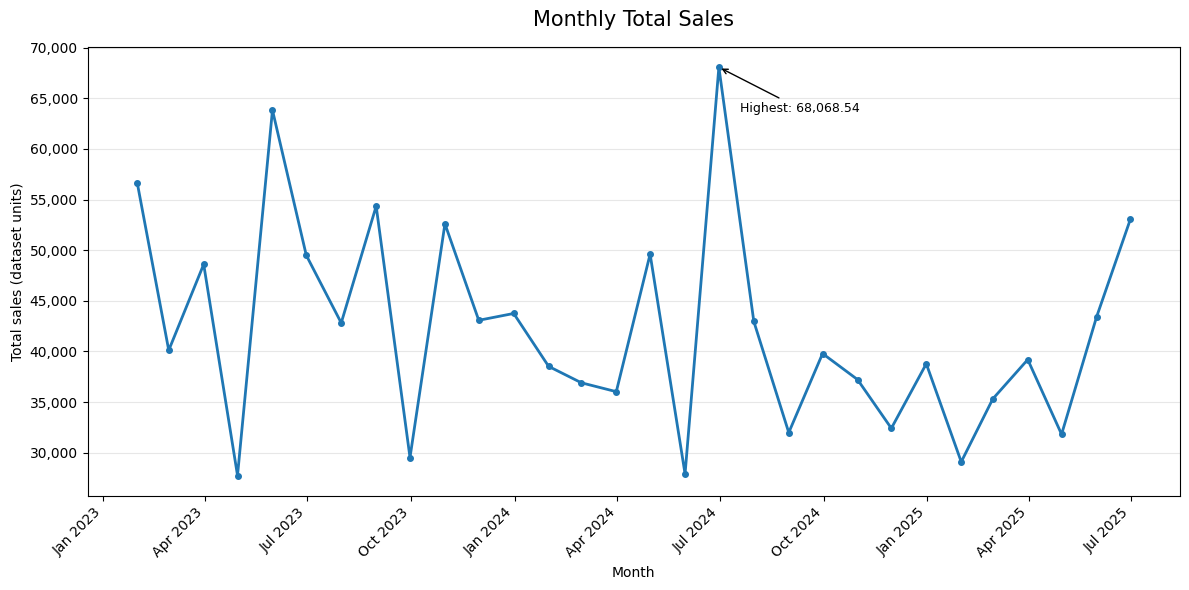

Updated chart saved to: ..\images\06_monthly_total_sales_trend.png


In [84]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter
from pathlib import Path

# Keep the existing project folder structure
images_folder = Path("../images")
images_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    sales_chart_data["Date"],
    sales_chart_data["TotalSales"],
    marker="o",
    markersize=4,
    linewidth=2
)

# Highlight the month with the highest total sales
highest_sales_row = sales_chart_data.loc[
    sales_chart_data["TotalSales"].idxmax()
]

ax.annotate(
    f"Highest: {highest_sales_row['TotalSales']:,.2f}",
    xy=(
        highest_sales_row["Date"],
        highest_sales_row["TotalSales"]
    ),
    xytext=(15, -25),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=9,
    arrowprops={"arrowstyle": "->"}
)

ax.set_title(
    "Monthly Total Sales",
    fontsize=15,
    pad=15
)
ax.set_xlabel("Month")
ax.set_ylabel("Total sales (dataset units)")

# Show one date label every three months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Add thousands separators to the vertical axis
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

chart_path = images_folder / "06_monthly_total_sales_trend.png"
fig.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Updated chart saved to:", chart_path)

### Why This Version Is Easier to Read

The chart now displays fewer month labels, formats the sales axis with thousands separators and highlights the month with the highest total sales. The line and markers still show how sales changed over time, while the original monthly values remain unchanged.

The vertical axis uses "dataset units" because the currency has not yet been verified.

In [85]:
updated_chart_path = Path(
    "../images/06_monthly_total_sales_trend.png"
)

print("Updated chart exists:", updated_chart_path.is_file())

if updated_chart_path.is_file():
    print(
        "File size:",
        f"{updated_chart_path.stat().st_size:,}",
        "bytes"
    )

Updated chart exists: True
File size: 293,926 bytes


### Step 3A Review

Before moving to another chart, I will check that the revised chart displays correctly, the date labels are readable and the highest-sales month is highlighted without covering important information.

I will also confirm that the image has been saved in the existing images folder so it can be used in the project README later.

## Task 5: Improving the UnitPrice vs TotalPrice Scatter Plot

The earlier analysis found a Pearson correlation of approximately 0.717 between UnitPrice and TotalPrice.

I want this chart to show the relationship clearly while keeping its interpretation accurate. Since TotalPrice is calculated as Quantity multiplied by UnitPrice, part of the relationship comes from the way the total is calculated.

I will focus on showing the individual observations clearly rather than relying on a fitted line to tell the whole story.

### What I Want to Improve

- Use a clear title and descriptive axis labels.
- Make overlapping observations easier to see.
- Keep the chart focused on the actual data points.
- Avoid implying that correlation proves causation.
- Save the revised chart separately so the original remains available for comparison.

In [86]:
# Select the two variables used in this chart
scatter_data = correlation_df[
    ["UnitPrice", "TotalPrice", "Quantity"]
].copy()

print("Records available:", len(scatter_data))
print("\nMissing values:")
display(scatter_data.isnull().sum().to_frame("Missing Values"))

print("\nSummary of the variables:")
display(scatter_data[["UnitPrice", "TotalPrice"]].describe().round(2))

Records available: 1200

Missing values:


,Missing Values
UnitPrice,0
TotalPrice,0
Quantity,0



Summary of the variables:


,UnitPrice,TotalPrice
count,1200.00,1200.00
mean,356.41,1053.97
std,197.18,819.86
min,11.39,11.39
25%,186.06,410.52
50%,364.21,823.62
75%,521.57,1578.48
max,699.93,3456.40


### Checking the Data

I will use the same observations as the earlier correlation analysis. Before creating the chart, I will check the number of records and missing values so that the visual is based on the expected data.

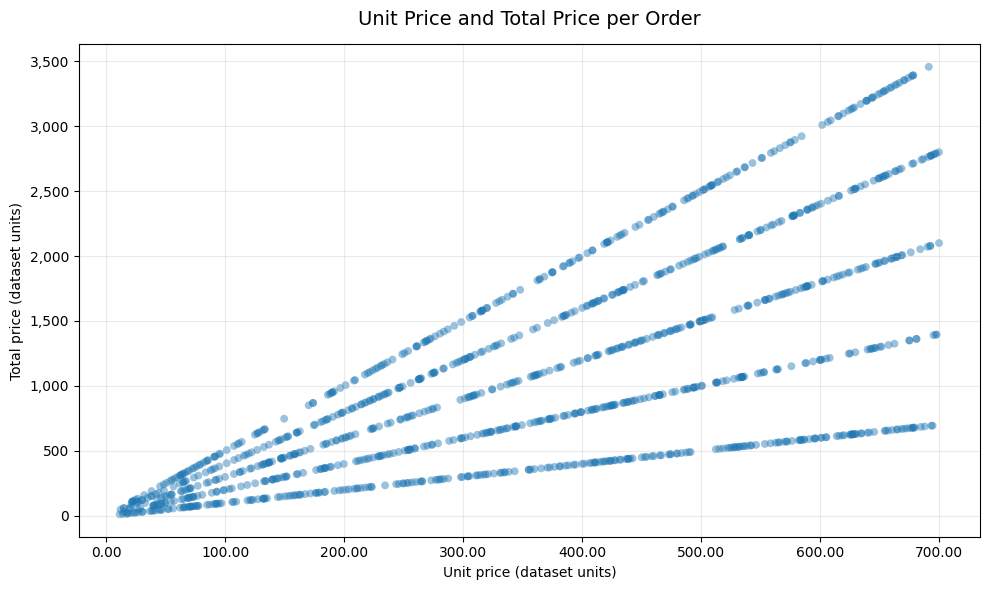

Records plotted: 1200
Updated chart saved to: ..\images\15_unitprice_vs_totalprice_review.png


In [87]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Keep the revised chart separate from the original
images_folder = Path("../images")
images_folder.mkdir(parents=True, exist_ok=True)

# Use complete records for the two plotted variables
plot_data = scatter_data.dropna(
    subset=["UnitPrice", "TotalPrice"]
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    plot_data["UnitPrice"],
    plot_data["TotalPrice"],
    alpha=0.45,
    s=32,
    edgecolors="none"
)

ax.set_title(
    "Unit Price and Total Price per Order",
    fontsize=14,
    pad=14
)
ax.set_xlabel("Unit price (dataset units)")
ax.set_ylabel("Total price (dataset units)")

ax.xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.2f}")
)
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.grid(True, alpha=0.25)
fig.tight_layout()

scatter_chart_path = (
    images_folder / "15_unitprice_vs_totalprice_review.png"
)

fig.savefig(
    scatter_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Records plotted:", len(plot_data))
print("Updated chart saved to:", scatter_chart_path)

### Why I Have Not Added a Regression Line

A fitted line can be useful when exploring a linear relationship, but it does not explain the full relationship in this case. TotalPrice is calculated from both Quantity and UnitPrice, so the pattern is partly determined by the pricing formula.

Showing the observations directly helps me examine their spread without suggesting that UnitPrice alone determines TotalPrice.

In [88]:
print("Updated chart exists:", scatter_chart_path.is_file())

if scatter_chart_path.is_file():
    print(
        "Image size:",
        f"{scatter_chart_path.stat().st_size:,}",
        "bytes"
    )

Updated chart exists: True
Image size: 470,106 bytes


### Step 3B Review

I will inspect the revised scatter plot to check that the points are visible, the axis labels are clear and the chart is not overcrowded.

The correlation result remains approximately 0.717 from the earlier analysis. This visual is intended to improve how the relationship is presented, not to change the underlying analysis or claim a causal relationship.

## Task 5: Improving the TotalPrice Boxplot

The earlier outlier analysis identified eight TotalPrice values beyond the IQR limits. I want the boxplot to make these unusually high values easier to understand.

I will keep all observations in the chart and calculate the IQR limits again from the available data. This provides a clear way to check the flagged values without assuming that they are errors.

### What I Want to Improve

- Show the distribution of TotalPrice clearly.
- Make the IQR outlier limits explicit.
- Count the observations outside those limits.
- Keep the full dataset in the analysis.
- Save the revised chart separately from the original boxplot.

In [89]:
# Use the TotalPrice values from the existing correlation dataset
total_price_data = (
    correlation_df["TotalPrice"]
    .dropna()
    .astype(float)
)

q1 = total_price_data.quantile(0.25)
q3 = total_price_data.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (
    (total_price_data < lower_bound)
    | (total_price_data > upper_bound)
)

print("Total records with a TotalPrice value:", len(total_price_data))
print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower IQR limit: {lower_bound:,.2f}")
print(f"Upper IQR limit: {upper_bound:,.2f}")
print("IQR-flagged values:", int(outlier_mask.sum()))

Total records with a TotalPrice value: 1200
Q1: 410.52
Q3: 1,578.47
IQR: 1,167.95
Lower IQR limit: -1,341.41
Upper IQR limit: 3,330.41
IQR-flagged values: 8


### Understanding the IQR Limits

The IQR is the difference between the third quartile (Q3) and the first quartile (Q1). Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged by this rule.

These limits identify observations that deserve investigation. They do not establish that the observations are incorrect.

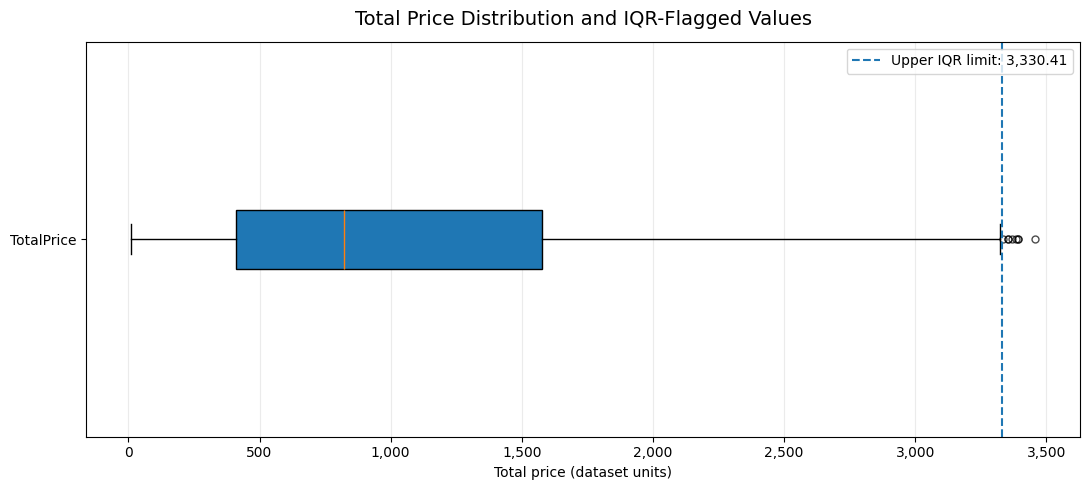

Updated boxplot saved to: ..\images\16_totalprice_boxplot_review.png


In [90]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from pathlib import Path

images_folder = Path("../images")
images_folder.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 5))

ax.boxplot(
    total_price_data,
    vert=False,
    patch_artist=True,
    showfliers=True,
    flierprops={
        "marker": "o",
        "markersize": 5,
        "markerfacecolor": "none",
        "markeredgecolor": "black",
        "alpha": 0.7
    }
)

# Mark the upper IQR limit for reference
ax.axvline(
    upper_bound,
    linestyle="--",
    linewidth=1.5,
    label=f"Upper IQR limit: {upper_bound:,.2f}"
)

ax.set_title(
    "Total Price Distribution and IQR-Flagged Values",
    fontsize=14,
    pad=12
)
ax.set_xlabel("Total price (dataset units)")
ax.set_yticks([1])
ax.set_yticklabels(["TotalPrice"])
ax.xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

ax.grid(axis="x", alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()

boxplot_path = (
    images_folder / "16_totalprice_boxplot_review.png"
)

fig.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Updated boxplot saved to:", boxplot_path)

### Interpreting the Revised Boxplot

The box represents the middle 50% of TotalPrice values, and the whiskers show the range covered by the boxplot rule. Individual points beyond the whiskers represent potential outliers.

The dashed vertical line marks the upper IQR limit. Points to its right are above that threshold. The chart shows where the unusual values occur, but further investigation is needed to decide whether any should be corrected or removed.

In [91]:
print("Updated chart exists:", boxplot_path.is_file())

if boxplot_path.is_file():
    print(
        "Image size:",
        f"{boxplot_path.stat().st_size:,}",
        "bytes"
    )

print("IQR-flagged values:", int(outlier_mask.sum()))

Updated chart exists: True
Image size: 84,944 bytes
IQR-flagged values: 8


### Step 3C Review

I will check that the boxplot is readable, the upper IQR limit is visible and the flagged values can be distinguished from the main distribution.

The outlier count should be consistent with the earlier analysis. I will keep the full set of observations and use the chart to support the interpretation rather than treating the IQR rule as an automatic data-cleaning decision.

## Task 5: Final Visual-Evidence Review

The charts created in the earlier tasks help explain distributions, monthly trends, unusual values and relationships between numerical variables. I have also improved three charts to make their presentation clearer.

Before completing this task, I will check that the expected chart files are present and that each visual has a clear purpose. The aim is to support the analysis with useful evidence, not simply to produce more charts.

### What I Will Check

- Whether the expected chart files exist.
- Whether each chart supports a specific part of the analysis.
- Whether the titles, labels and scales are understandable.
- Whether unusual values are explained rather than automatically treated as errors.
- Whether the charts support the findings without implying causation where it has not been established.

In [92]:
from pathlib import Path
import pandas as pd

images_folder = Path("../images")

final_chart_inventory = [
    ("Quantity distribution", "01_quantity_distribution.png", "Distribution"),
    ("Unit price distribution", "02_unit_price_distribution.png", "Distribution"),
    ("Items in cart distribution", "03_items_in_cart_distribution.png", "Distribution"),
    ("Total price distribution", "04_total_price_distribution.png", "Distribution"),
    ("Monthly order trend", "05_monthly_order_trend.png", "Trend"),
    ("Monthly total sales trend", "06_monthly_total_sales_trend.png", "Trend"),
    ("Quantity boxplot", "07_boxplot_quantity.png", "Outliers"),
    ("Unit price boxplot", "08_boxplot_unit_price.png", "Outliers"),
    ("Items in cart boxplot", "09_boxplot_items_in_cart.png", "Outliers"),
    ("Total price boxplot", "10_boxplot_total_price.png", "Outliers"),
    ("Correlation heatmap", "11_correlation_heatmap.png", "Relationships"),
    ("Unit price vs total price", "12_unitprice_vs_totalprice.png", "Relationships"),
    ("Quantity vs total price", "13_quantity_vs_totalprice.png", "Relationships"),
    ("Items in cart vs total price", "14_itemsincart_vs_totalprice.png", "Relationships"),
    ("Reviewed unit price vs total price", "15_unitprice_vs_totalprice_review.png", "Reviewed visual"),
    ("Reviewed TotalPrice boxplot", "16_totalprice_boxplot_review.png", "Reviewed visual"),
]

final_chart_df = pd.DataFrame(
    final_chart_inventory,
    columns=["Chart", "Filename", "Purpose"]
)

final_chart_df["File Exists"] = final_chart_df["Filename"].apply(
    lambda filename: (images_folder / filename).is_file()
)

display(final_chart_df)

,Chart,Filename,Purpose,File Exists
0,Quantity distribution,01_quantity_distribution.png,Distribution,True
1,Unit price distribution,02_unit_price_distribution.png,Distribution,True
2,Items in cart distribution,03_items_in_cart_distribution.png,Distribution,True
3,Total price distribution,04_total_price_distribution.png,Distribution,True
4,Monthly order trend,05_monthly_order_trend.png,Trend,True
5,Monthly total sales trend,06_monthly_total_sales_trend.png,Trend,True
6,Quantity boxplot,07_boxplot_quantity.png,Outliers,True
7,Unit price boxplot,08_boxplot_unit_price.png,Outliers,True
8,Items in cart boxplot,09_boxplot_items_in_cart.png,Outliers,True
9,Total price boxplot,10_boxplot_total_price.png,Outliers,True


### Checking the Chart Files

The inventory checks whether the expected images are present in the project's images folder. A missing file needs to be investigated before the project is finalised.

The updated monthly sales chart uses the existing filename, so it is included only once in the inventory. The scatter plot and TotalPrice boxplot revisions have separate filenames to preserve their original versions.

In [93]:
missing_chart_files = final_chart_df.loc[
    ~final_chart_df["File Exists"],
    ["Chart", "Filename"]
]

print("Expected chart files:", len(final_chart_df))
print("Files found:", int(final_chart_df["File Exists"].sum()))
print("Files missing:", len(missing_chart_files))

if missing_chart_files.empty:
    print("All expected chart files were found.")
else:
    print("Please investigate these missing files:")
    display(missing_chart_files.reset_index(drop=True))

Expected chart files: 16
Files found: 16
Files missing: 0
All expected chart files were found.


### Connecting Visuals to Findings

Each group of charts serves a different purpose:

- **Distributions:** show how values are spread across orders.
- **Monthly trends:** show how order counts and sales change over time.
- **Boxplots:** help identify unusually high or low observations.
- **Heatmap and scatter plots:** show the strength, direction and shape of relationships.

The visuals should be interpreted alongside the descriptive statistics and earlier analysis. A chart can highlight a pattern, but it does not by itself establish why that pattern occurred.

In [94]:
purpose_summary = (
    final_chart_df.groupby("Purpose")
    .size()
    .reset_index(name="Number of Charts")
    .sort_values("Number of Charts", ascending=False)
)

display(purpose_summary)

print(
    "Chart inventory complete:",
    len(final_chart_df) == 16
)

,Purpose,Number of Charts
0,Distribution,4
1,Outliers,4
2,Relationships,4
3,Reviewed visual,2
4,Trend,2


Chart inventory complete: True


### Task 5 Visual-Evidence Review Summary

The project now includes charts for distributions, trends, outliers and relationships, along with targeted improvements to selected visuals.

The final check confirms whether the expected image files are available. The charts will be used as evidence for the findings developed in the earlier tasks, with care taken to distinguish statistical patterns from confirmed explanations.

Once the file check has passed and the charts have been inspected, the visual-evidence work can be considered ready for documentation and final quality checks.